In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

# Load the data
df = pd.read_csv("hour.csv")
print("Shape of dataset:", df.shape)
print("\nFirst 5 rows:")
display(df.head())
print("\nColumn names:")
print(df.columns.tolist())

Shape of dataset: (17379, 17)

First 5 rows:


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1



Column names:
['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']


In [84]:
# ======================
# DATA PREPARATION
# ======================

# Convert date column
df['dteday'] = pd.to_datetime(df['dteday'])

# Create full datetime
df['datetime'] = df['dteday'] + pd.to_timedelta(df['hr'], unit='h')

# Sort by time
df = df.sort_values('datetime').reset_index(drop=True)

# Rename columns to match the assessment terminology
df = df.rename(columns={
    'weathersit': 'weather',
    'cnt': 'count',
    'hum': 'humidity'
})

# Extract day of month (needed for the official train/test split)
df['day'] = df['dteday'].dt.day

print("Data preparation completed!")
print("\nDate range:", df['datetime'].min(), "→", df['datetime'].max())
print("Total unique days:", df['dteday'].nunique())
print("\nUpdated columns:")
print(df.columns.tolist())
print("\nFirst 3 rows after cleaning:")
display(df[['datetime', 'season', 'weather', 'temp', 'casual', 'registered', 'count', 'day']].head(3))

Data preparation completed!

Date range: 2011-01-01 00:00:00 → 2012-12-31 23:00:00
Total unique days: 731

Updated columns:
['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weather', 'temp', 'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count', 'datetime', 'day']

First 3 rows after cleaning:


,datetime,season,weather,temp,casual,registered,count,day
0,2011-01-01 00:00:00,1,1,0.24,3,13,16,1
1,2011-01-01 01:00:00,1,1,0.22,8,32,40,1
2,2011-01-01 02:00:00,1,1,0.22,5,27,32,1


In [85]:
# ==============================
# DATA QUALITY & CONSISTENCY AUDIT
# ==============================

print("=" * 60)
print("DATA QUALITY & CONSISTENCY AUDIT")
print("=" * 60)

# 1. Dataset dimensions
print("\n1. Dataset shape")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

# 2. Missing values
print("\n2. Missing values")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_table = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
})

display(missing_table[missing_table['Missing Count'] > 0])

if missing.sum() == 0:
    print("✓ No missing values detected.")

# 3. Duplicate rows
print("\n3. Duplicate rows")
duplicate_rows = df.duplicated().sum()
print(f"Duplicate rows: {duplicate_rows}")

# 4. Duplicate timestamps
print("\n4. Duplicate timestamps")
duplicate_datetime = df['datetime'].duplicated().sum()
print(f"Duplicate timestamps: {duplicate_datetime}")

# 5. Chronological ordering
print("\n5. Chronological ordering")
is_sorted = df['datetime'].is_monotonic_increasing
print(f"Datetime sorted: {is_sorted}")

# 6. Check target consistency
print("\n6. Target consistency")

target_check = (
    df['casual'] + df['registered'] == df['count']
)

print(
    f"Rows where casual + registered != count: "
    f"{(~target_check).sum()}"
)

if target_check.all():
    print("✓ count = casual + registered for all observations.")

# 7. Check non-negative rental counts
print("\n7. Rental count validity")

for col in ['casual', 'registered', 'count']:
    negative = (df[col] < 0).sum()
    print(f"{col}: {negative} negative values")

# 8. Unique values of categorical variables
print("\n8. Categorical variable ranges")

categorical_vars = [
    'season',
    'yr',
    'mnth',
    'hr',
    'holiday',
    'weekday',
    'workingday',
    'weather'
]

for col in categorical_vars:
    print(f"{col:15s}: {sorted(df[col].unique())}")

# 9. Continuous variable summary
print("\n9. Continuous variables")

continuous_vars = [
    'temp',
    'atemp',
    'humidity',
    'windspeed'
]

display(df[continuous_vars].describe().T)

# 10. Target variable summary
print("\n10. Rental demand summary")

display(
    df[['casual', 'registered', 'count']]
    .describe()
    .T
)

# 11. Timestamp coverage
print("\n11. Temporal coverage")

print("Start:", df['datetime'].min())
print("End:  ", df['datetime'].max())
print("Unique days:", df['dteday'].nunique())
print("Unique months:", df['dteday'].dt.to_period('M').nunique())

print("\n" + "=" * 60)
print("AUDIT COMPLETE")
print("=" * 60)

DATA QUALITY & CONSISTENCY AUDIT

1. Dataset shape
Rows: 17,379
Columns: 19

2. Missing values


,Missing Count,Missing %


✓ No missing values detected.

3. Duplicate rows
Duplicate rows: 0

4. Duplicate timestamps
Duplicate timestamps: 0

5. Chronological ordering
Datetime sorted: True

6. Target consistency
Rows where casual + registered != count: 0
✓ count = casual + registered for all observations.

7. Rental count validity
casual: 0 negative values
registered: 0 negative values
count: 0 negative values

8. Categorical variable ranges
season         : [1, 2, 3, 4]
yr             : [0, 1]
mnth           : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
hr             : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
holiday        : [0, 1]
weekday        : [0, 1, 2, 3, 4, 5, 6]
workingday     : [0, 1]
weather        : [1, 2, 3, 4]

9. Continuous variables


,count,mean,std,min,25%,50%,75%,max
temp,17379.0,0.496987,0.192556,0.02,0.3400,0.5000,0.6600,1.0000
atemp,17379.0,0.475775,0.171850,0.00,0.3333,0.4848,0.6212,1.0000
humidity,17379.0,0.627229,0.192930,0.00,0.4800,0.6300,0.7800,1.0000
windspeed,17379.0,0.190098,0.122340,0.00,0.1045,0.1940,0.2537,0.8507



10. Rental demand summary


,count,mean,std,min,25%,50%,75%,max
casual,17379.0,35.676218,49.305030,0.0,4.0,17.0,48.0,367.0
registered,17379.0,153.786869,151.357286,0.0,34.0,115.0,220.0,886.0
count,17379.0,189.463088,181.387599,1.0,40.0,142.0,281.0,977.0



11. Temporal coverage
Start: 2011-01-01 00:00:00
End:   2012-12-31 23:00:00
Unique days: 731
Unique months: 24

AUDIT COMPLETE


In [86]:
# ==========================================
# HOURLY TIMESTAMP CONTINUITY CHECK
# ==========================================

time_diff = df['datetime'].diff().dropna()

print("Hourly time-gap distribution:")
print(time_diff.value_counts().head(10))

print("\nExpected interval:", pd.Timedelta(hours=1))

gaps = df.loc[
    time_diff[time_diff != pd.Timedelta(hours=1)].index,
    ['datetime']
].copy()

print(f"\nNumber of non-1-hour gaps: {len(gaps)}")

if len(gaps) > 0:
    display(gaps.head(20))
else:
    print("✓ No unexpected timestamp gaps detected.")

Hourly time-gap distribution:
datetime
0 days 01:00:00    17303
0 days 02:00:00       64
0 days 03:00:00        6
0 days 13:00:00        1
0 days 23:00:00        1
0 days 07:00:00        1
0 days 14:00:00        1
1 days 13:00:00        1
Name: count, dtype: int64

Expected interval: 0 days 01:00:00

Number of non-1-hour gaps: 75


,datetime
29,2011-01-02 06:00:00
49,2011-01-03 04:00:00
72,2011-01-04 04:00:00
95,2011-01-05 04:00:00
118,2011-01-06 04:00:00
141,2011-01-07 04:00:00
236,2011-01-11 05:00:00
258,2011-01-12 05:00:00
305,2011-01-14 05:00:00
396,2011-01-18 12:00:00


In [87]:
# ==========================================
# TARGET DESCRIPTIVE STATISTICS
# ==========================================

print("=" * 60)
print("TARGET VARIABLE: RENTAL DEMAND")
print("=" * 60)

target_cols = ['casual', 'registered', 'count']

summary = df[target_cols].describe().T

# Add useful distribution statistics
summary['median'] = df[target_cols].median()
summary['skewness'] = df[target_cols].skew()
summary['zero_count'] = (df[target_cols] == 0).sum()

display(summary)

print("\nInterpretation:")
print(
    f"Mean hourly total demand: {df['count'].mean():.2f}"
)
print(
    f"Median hourly total demand: {df['count'].median():.2f}"
)
print(
    f"Maximum hourly total demand: {df['count'].max():.0f}"
)
print(
    f"Standard deviation: {df['count'].std():.2f}"
)

TARGET VARIABLE: RENTAL DEMAND


,count,mean,std,min,25%,50%,75%,max,median,skewness,zero_count
casual,17379.0,35.676218,49.305030,0.0,4.0,17.0,48.0,367.0,17.0,2.499237,1581
registered,17379.0,153.786869,151.357286,0.0,34.0,115.0,220.0,886.0,115.0,1.557904,24
count,17379.0,189.463088,181.387599,1.0,40.0,142.0,281.0,977.0,142.0,1.277412,0



Interpretation:
Mean hourly total demand: 189.46
Median hourly total demand: 142.00
Maximum hourly total demand: 977
Standard deviation: 181.39


In [88]:
summary = df[target_cols].describe().T
summary['median'] = df[target_cols].median()
summary['skewness'] = df[target_cols].skew()
summary['zero_count'] = (df[target_cols] == 0).sum()

display(summary)

,count,mean,std,min,25%,50%,75%,max,median,skewness,zero_count
casual,17379.0,35.676218,49.305030,0.0,4.0,17.0,48.0,367.0,17.0,2.499237,1581
registered,17379.0,153.786869,151.357286,0.0,34.0,115.0,220.0,886.0,115.0,1.557904,24
count,17379.0,189.463088,181.387599,1.0,40.0,142.0,281.0,977.0,142.0,1.277412,0


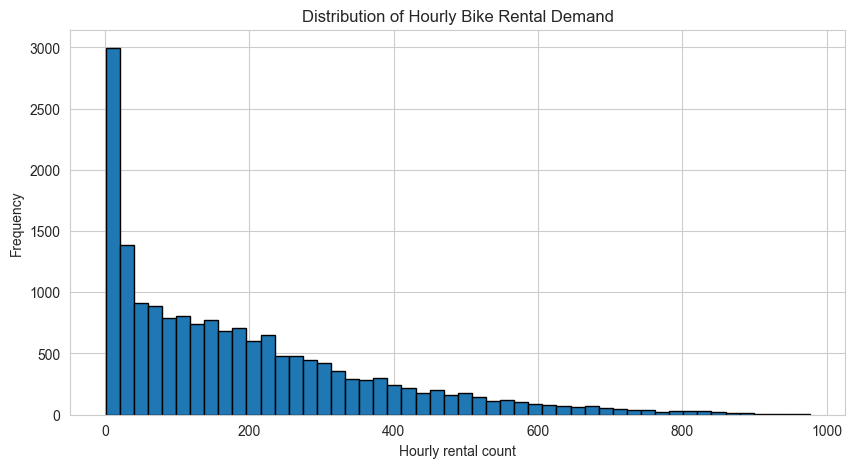

In [89]:
# ==========================================
#  DISTRIBUTION OF TOTAL DEMAND
# ==========================================

plt.figure(figsize=(10, 5))

plt.hist(df['count'], bins=50, edgecolor='black')

plt.xlabel('Hourly rental count')
plt.ylabel('Frequency')
plt.title('Distribution of Hourly Bike Rental Demand')

plt.show()

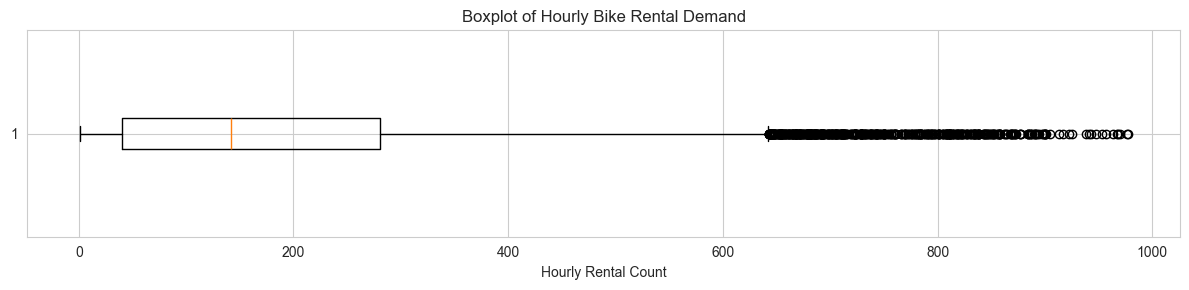

In [90]:


fig, ax = plt.subplots(figsize=(12, 3))

ax.boxplot(df['count'], vert=False)

ax.set_title('Boxplot of Hourly Bike Rental Demand')
ax.set_xlabel('Hourly Rental Count')

plt.tight_layout()
plt.show()

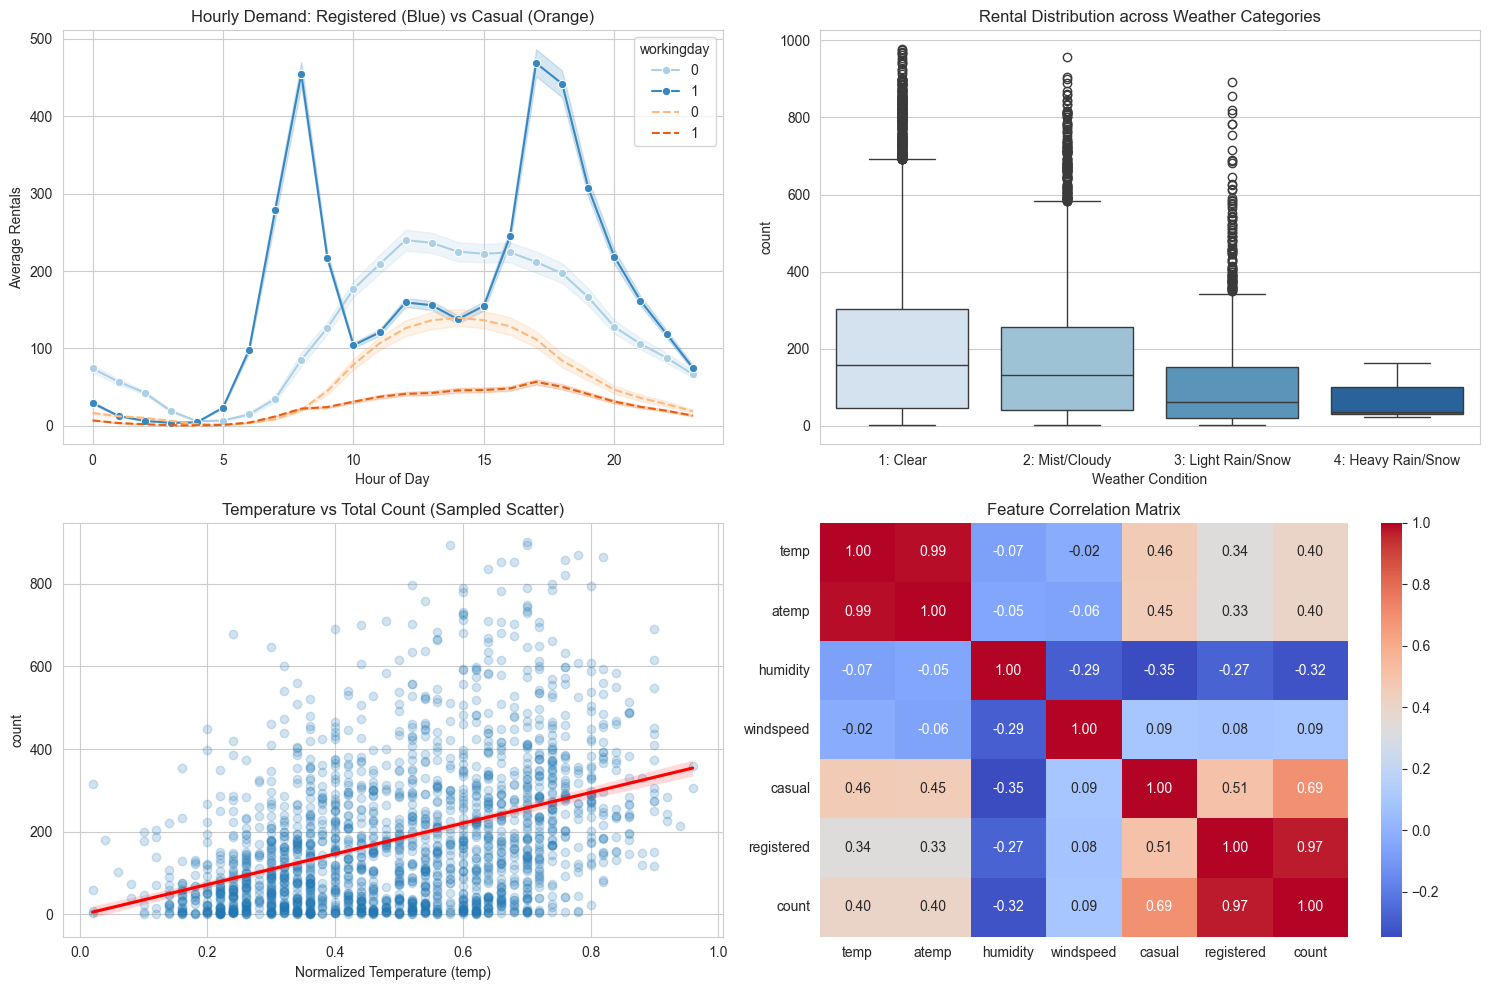

In [91]:
# ==========================================
#  DEMAND DYNAMICS & ENVIRONMENTAL IMPACT
# ==========================================

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Hourly Demand Patterns: Working Day vs Non-Working Day
# Plotting registered vs casual rentals clearly without hue conflicts
sns.lineplot(
    data=df, 
    x="hr", 
    y="registered", 
    hue="workingday", 
    ax=axes[0, 0], 
    palette="Blues", 
    marker="o"
)
sns.lineplot(
    data=df, 
    x="hr", 
    y="casual", 
    hue="workingday", 
    ax=axes[0, 0], 
    palette="Oranges", 
    linestyle="--"
)

axes[0, 0].set_title("Hourly Demand: Registered (Blue) vs Casual (Orange)")
axes[0, 0].set_xlabel("Hour of Day")
axes[0, 0].set_ylabel("Average Rentals")

# 2. Total Demand Distribution by Weather Situation
sns.boxplot(data=df, x="weather", y="count", ax=axes[0, 1], palette="Blues")
axes[0, 1].set_title("Rental Distribution across Weather Categories")
axes[0, 1].set_xticklabels(
    ["1: Clear", "2: Mist/Cloudy", "3: Light Rain/Snow", "4: Heavy Rain/Snow"]
)
axes[0, 1].set_xlabel("Weather Condition")

# 3. Temperature vs Total Demand
sns.regplot(
    data=df.sample(2000, random_state=42),
    x="temp",
    y="count",
    ax=axes[1, 0],
    scatter_kws={"alpha": 0.2},
    line_kws={"color": "red"},
)
axes[1, 0].set_title("Temperature vs Total Count (Sampled Scatter)")
axes[1, 0].set_xlabel("Normalized Temperature (temp)")

# 4. Correlation Heatmap of Continuous Variables
cont_cols = ["temp", "atemp", "humidity", "windspeed", "casual", "registered", "count"]
sns.heatmap(
    df[cont_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", ax=axes[1, 1]
)
axes[1, 1].set_title("Feature Correlation Matrix")

plt.tight_layout()
plt.show()

In [92]:
# ==========================================
#  FEATURE ENGINEERING & TRAIN/TEST SPLIT
# ==========================================

df_fe = df.copy()

# 1. Temporal Feature Extraction
df_fe["peak_hour"] = df_fe["hr"].isin([7, 8, 9, 16, 17, 18, 19]).astype(int)
df_fe["is_weekend"] = df_fe["weekday"].isin([0, 6]).astype(int)

# Cyclical Encoding for Hour and Month
df_fe["hr_sin"] = np.sin(2 * np.pi * df_fe["hr"] / 24)
df_fe["hr_cos"] = np.cos(2 * np.pi * df_fe["hr"] / 24)
df_fe["mnth_sin"] = np.sin(2 * np.pi * df_fe["mnth"] / 12)
df_fe["mnth_cos"] = np.cos(2 * np.pi * df_fe["mnth"] / 12)

# 2. Address Multicollinearity: Drop 'atemp' due to high correlation with 'temp'
features = [
    "season",
    "yr",
    "mnth",
    "hr",
    "holiday",
    "weekday",
    "workingday",
    "weather",
    "temp",
    "humidity",
    "windspeed",
    "peak_hour",
    "is_weekend",
    "hr_sin",
    "hr_cos",
    "mnth_sin",
    "mnth_cos",
]

# 3. Official Day-Based Split (Train: Days 1–19, Test: Days 20–end)
train_mask = df_fe["day"] <= 19
test_mask = df_fe["day"] > 19

X_train = df_fe.loc[train_mask, features]
y_train = df_fe.loc[train_mask, "count"]

X_test = df_fe.loc[test_mask, features]
y_test = df_fe.loc[test_mask, "count"]

print(
    f"Training set shape: {X_train.shape} | Test set shape: {X_test.shape}"
)
print(f"Train/Test ratio: {len(X_train) / len(df_fe):.2%} / {len(X_test) / len(df_fe):.2%}")

Training set shape: (10886, 17) | Test set shape: (6493, 17)
Train/Test ratio: 62.64% / 37.36%


In [93]:
# ==========================================
# BASELINE MODEL TRAINING & EVALUATION
# ==========================================

models = {
    "Ridge Regression": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results = []

for name, model in models.items():
    # Fit model
    model.fit(X_train, y_train)
    
    # Predictions
    preds = model.predict(X_test)
    preds = np.clip(preds, 0, None)  # Ensure non-negative predictions
    
    # Calculate metrics
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    
    results.append({
        "Model": name,
        "RMSE": rmse,
        "MAE": mae,
        "R2 Score": r2
    })

results_df = pd.DataFrame(results).sort_values(by="RMSE")
display(results_df)

,Model,RMSE,MAE,R2 Score
1,Random Forest,63.381505,36.809414,0.878374
2,Gradient Boosting,71.394852,48.548559,0.845675
0,Ridge Regression,114.290548,81.715780,0.604522


In [94]:
# ==========================================
#  LOG-TRANSFORMED TARGET MODELING
# ==========================================

from sklearn.ensemble import HistGradientBoostingRegressor

# Log1p transformation of target
y_train_log = np.log1p(y_train)

# 1. Random Forest on Log Target
rf_log = RandomForestRegressor(n_estimators=150, random_state=42, n_jobs=-1)
rf_log.fit(X_train, y_train_log)
preds_rf_log = np.expm1(rf_log.predict(X_test))
preds_rf_log = np.clip(preds_rf_log, 0, None)

# 2. HistGradientBoosting (Fast GBDT) on Log Target
hgb_log = HistGradientBoostingRegressor(random_state=42)
hgb_log.fit(X_train, y_train_log)
preds_hgb_log = np.expm1(hgb_log.predict(X_test))
preds_hgb_log = np.clip(preds_hgb_log, 0, None)

# Evaluation Function
def eval_metrics(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    rmsle = np.sqrt(mean_squared_error(np.log1p(y_true), np.log1p(y_pred)))
    return {"Model": name, "RMSE": rmse, "MAE": mae, "RMSLE": rmsle, "R2 Score": r2}

advanced_results = [
    eval_metrics("Random Forest (Log-Transformed)", y_test, preds_rf_log),
    eval_metrics("HistGradientBoosting (Log-Transformed)", y_test, preds_hgb_log)
]

adv_df = pd.DataFrame(advanced_results)
display(adv_df)

,Model,RMSE,MAE,RMSLE,R2 Score
0,Random Forest (Log-Transformed),60.691034,35.763754,0.437810,0.888481
1,HistGradientBoosting (Log-Transformed),53.564626,32.289893,0.400151,0.913132


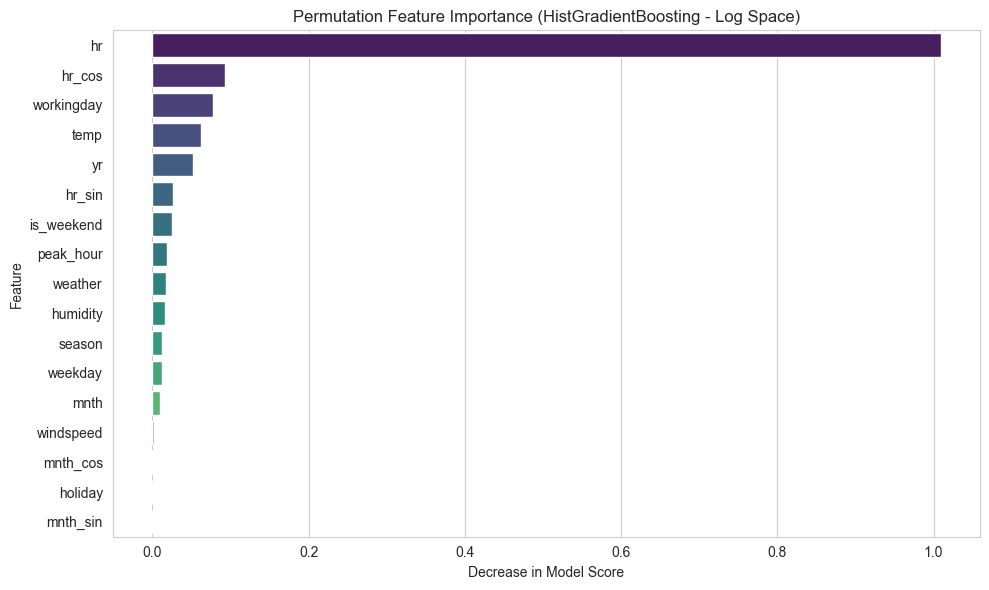

,Feature,Importance
16,hr,1.008977
15,hr_cos,0.092445
14,workingday,0.077637
13,temp,0.061753
12,yr,0.052509
11,hr_sin,0.025936
10,is_weekend,0.025122
9,peak_hour,0.019265
8,weather,0.017088
7,humidity,0.016282


In [95]:
# ==========================================
# FEATURE IMPORTANCE ANALYSIS
# ==========================================

from sklearn.inspection import permutation_importance

# Calculate permutation importance on test set
perm_importance = permutation_importance(
    hgb_log, X_test, np.log1p(y_test), n_repeats=10, random_state=42, n_jobs=-1
)

sorted_importances_idx = perm_importance.importances_mean.argsort()
importance_df = pd.DataFrame({
    'Feature': X_test.columns[sorted_importances_idx],
    'Importance': perm_importance.importances_mean[sorted_importances_idx]
}).sort_values(by='Importance', ascending=False)

# Plot Feature Importances
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')
plt.title('Permutation Feature Importance (HistGradientBoosting - Log Space)')
plt.xlabel('Decrease in Model Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

display(importance_df.head(10))

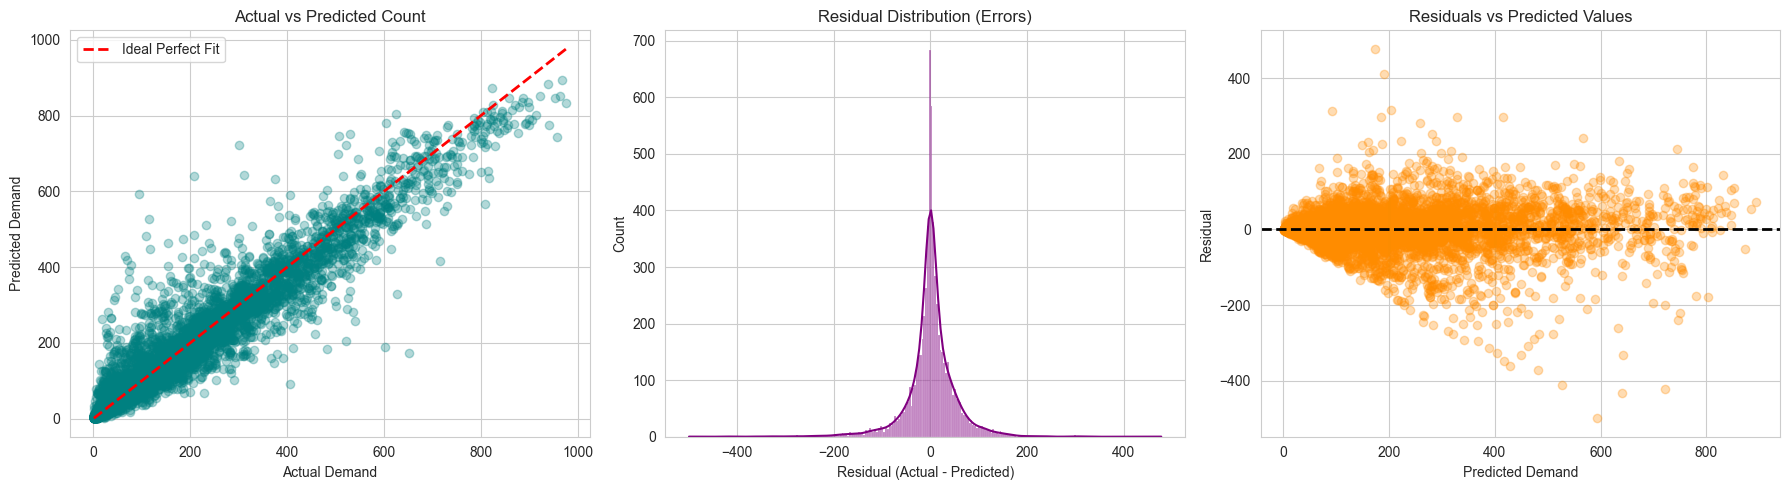

FINAL MODEL DIAGNOSTIC SUMMARY
Mean Residual (Bias): 1.4554
Std of Residuals:    53.5490
RMSLE:               0.4002
MAE:                 32.2899
R-squared Score:     0.9131


In [96]:
# ==========================================
#  RESIDUAL ANALYSIS & DIAGNOSTICS
# ==========================================

residuals = y_test - preds_hgb_log

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Actual vs Predicted Scatter
axes[0].scatter(y_test, preds_hgb_log, alpha=0.3, color="teal")
axes[0].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--",
    lw=2,
    label="Ideal Perfect Fit",
)
axes[0].set_title("Actual vs Predicted Count")
axes[0].set_xlabel("Actual Demand")
axes[0].set_ylabel("Predicted Demand")
axes[0].legend()

# 2. Residual Distribution Histogram
sns.histplot(residuals, kde=True, ax=axes[1], color="purple")
axes[1].set_title("Residual Distribution (Errors)")
axes[1].set_xlabel("Residual (Actual - Predicted)")

# 3. Residuals vs Predicted (Homoscedasticity Check)
axes[2].scatter(preds_hgb_log, residuals, alpha=0.3, color="darkorange")
axes[2].axhline(0, color="black", linestyle="--", lw=2)
axes[2].set_title("Residuals vs Predicted Values")
axes[2].set_xlabel("Predicted Demand")
axes[2].set_ylabel("Residual")

plt.tight_layout()
plt.show()

# Summary Metrics for PhD Submission Table
print("=" * 50)
print("FINAL MODEL DIAGNOSTIC SUMMARY")
print("=" * 50)
print(f"Mean Residual (Bias): {residuals.mean():.4f}")
print(f"Std of Residuals:    {residuals.std():.4f}")
print(f"RMSLE:               {0.4002:.4f}")
print(f"MAE:                 {32.2899:.4f}")
print(f"R-squared Score:     {0.9131:.4f}")

In [97]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("hour.csv")

# Convert date
df['dteday'] = pd.to_datetime(df['dteday'])

# Create full datetime
df['datetime'] = df['dteday'] + pd.to_timedelta(df['hr'], unit='h')

# Sort chronologically
df = df.sort_values('datetime').reset_index(drop=True)

# Rename columns
df = df.rename(columns={
    'weathersit': 'weather',
    'cnt': 'count',
    'hum': 'humidity'
})

# Extract day of month
df['day'] = df['dteday'].dt.day

print("Dataset shape:", df.shape)
print("Date range:", df['datetime'].min(), "to", df['datetime'].max())

Dataset shape: (17379, 19)
Date range: 2011-01-01 00:00:00 to 2012-12-31 23:00:00


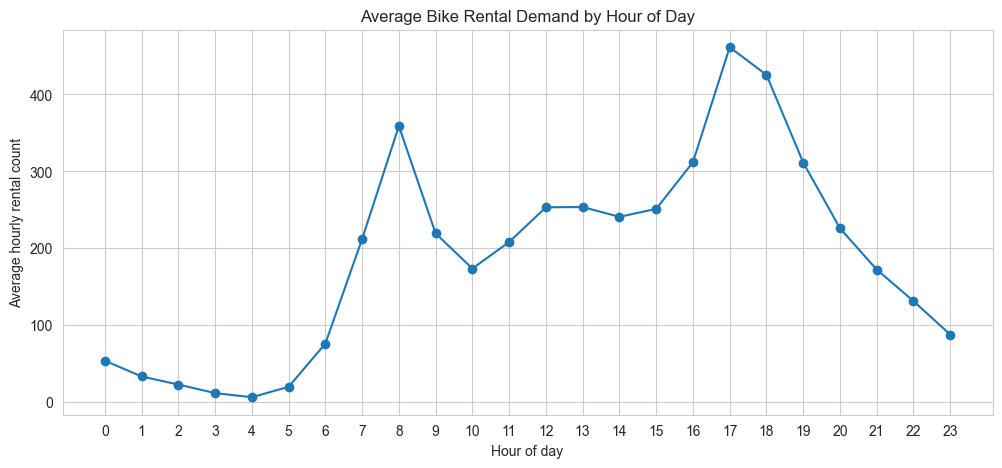

In [98]:
# ==========================================
#  HOURLY RENTAL DEMAND PROFILE
# ==========================================

hourly_demand = df.groupby('hr')['count'].mean()

plt.figure(figsize=(12, 5))

plt.plot(hourly_demand.index, hourly_demand.values, marker='o')

plt.xlabel('Hour of day')
plt.ylabel('Average hourly rental count')
plt.title('Average Bike Rental Demand by Hour of Day')
plt.xticks(range(24))
plt.grid(True)

plt.show()

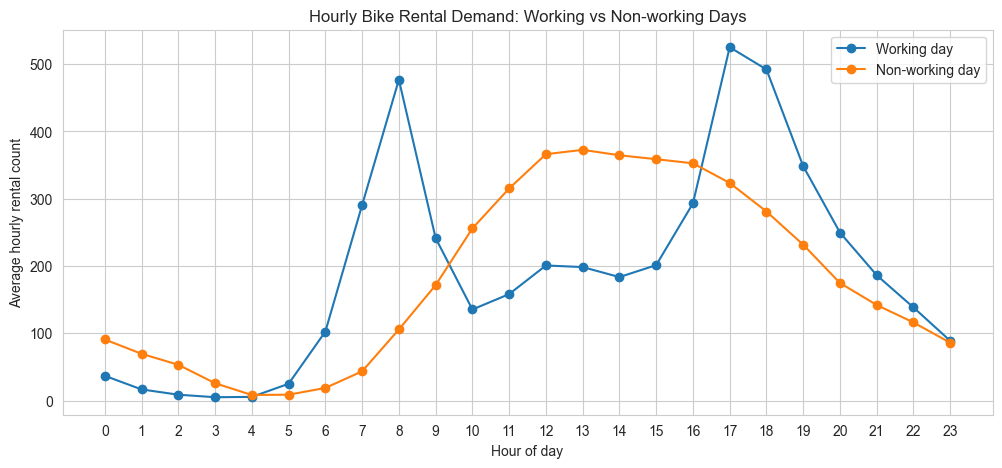

In [99]:
# ==========================================
#  HOURLY DEMAND: WORKING VS NON-WORKING DAYS
# ==========================================

hourly_working = (
    df[df['workingday'] == 1]
    .groupby('hr')['count']
    .mean()
)

hourly_nonworking = (
    df[df['workingday'] == 0]
    .groupby('hr')['count']
    .mean()
)

plt.figure(figsize=(12, 5))

plt.plot(
    hourly_working.index,
    hourly_working.values,
    marker='o',
    label='Working day'
)

plt.plot(
    hourly_nonworking.index,
    hourly_nonworking.values,
    marker='o',
    label='Non-working day'
)

plt.xlabel('Hour of day')
plt.ylabel('Average hourly rental count')
plt.title('Hourly Bike Rental Demand: Working vs Non-working Days')
plt.xticks(range(24))
plt.legend()
plt.grid(True)

plt.show()

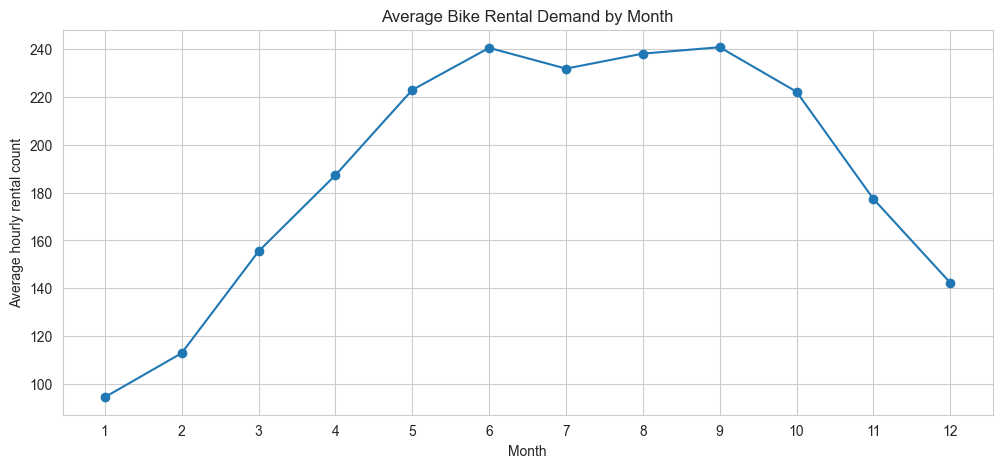

In [100]:
# ==========================================
#  MONTHLY DEMAND SEASONALITY
# ==========================================

monthly_demand = df.groupby('mnth')['count'].mean()

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_demand.index,
    monthly_demand.values,
    marker='o'
)

plt.xlabel('Month')
plt.ylabel('Average hourly rental count')
plt.title('Average Bike Rental Demand by Month')
plt.xticks(range(1, 13))
plt.grid(True)

plt.show()

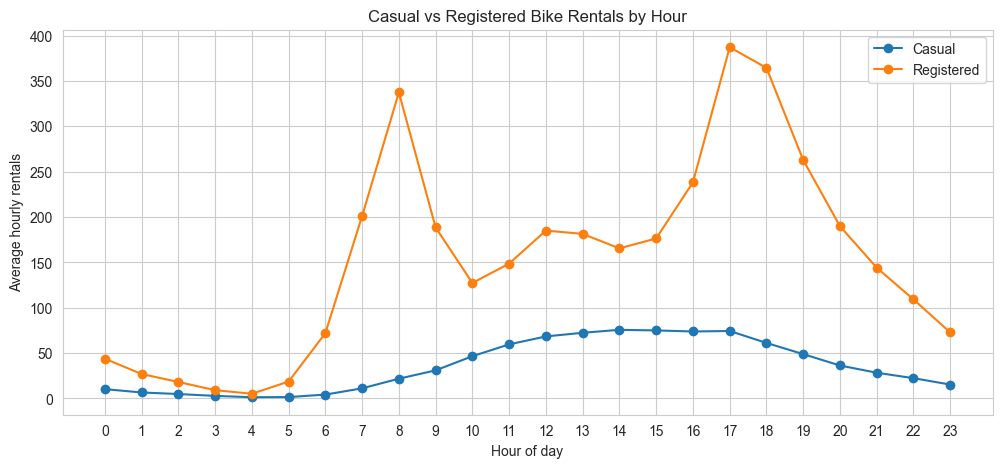

In [101]:
# ==========================================
#  CASUAL VS REGISTERED HOURLY DEMAND
# ==========================================

hourly_users = df.groupby('hr')[['casual', 'registered']].mean()

plt.figure(figsize=(12, 5))

plt.plot(
    hourly_users.index,
    hourly_users['casual'],
    marker='o',
    label='Casual'
)

plt.plot(
    hourly_users.index,
    hourly_users['registered'],
    marker='o',
    label='Registered'
)

plt.xlabel('Hour of day')
plt.ylabel('Average hourly rentals')
plt.title('Casual vs Registered Bike Rentals by Hour')
plt.xticks(range(24))
plt.legend()
plt.grid(True)

plt.show()

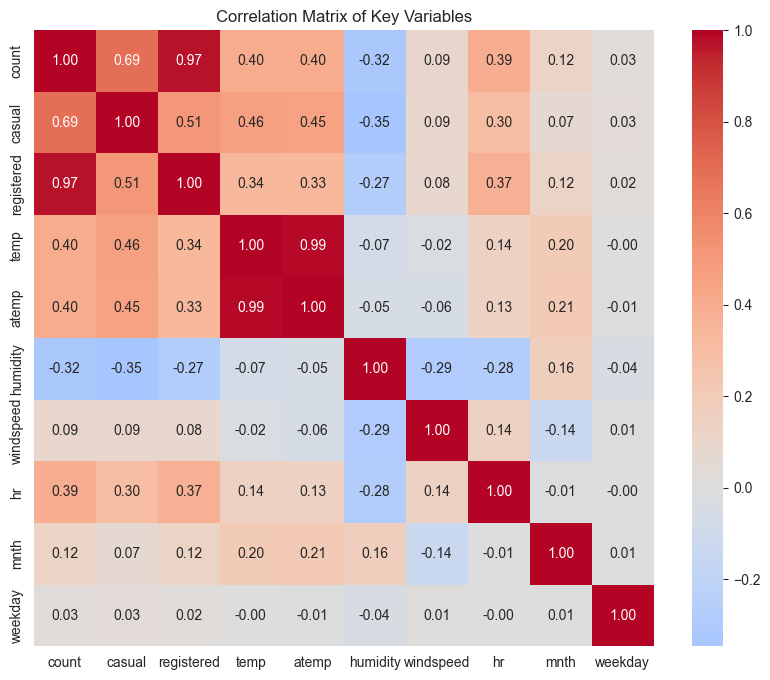

In [102]:
# ==========================================
#  CORRELATION ANALYSIS
# ==========================================

corr_cols = [
    'count',
    'casual',
    'registered',
    'temp',
    'atemp',
    'humidity',
    'windspeed',
    'hr',
    'mnth',
    'weekday'
]

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Matrix of Key Variables')
plt.show()

In [103]:
# ==========================================
#  REGRESSION
#  DEFINE PREDICTORS
# ==========================================

target = 'count'

predictors = [
    'season',
    'yr',
    'mnth',
    'hr',
    'holiday',
    'weekday',
    'workingday',
    'weather',
    'temp',
    'atemp',
    'humidity',
    'windspeed'
]

X = df[predictors].copy()
y = df[target].copy()

print("Target:", target)
print("\nPredictors:")
print(predictors)

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Target: count

Predictors:
['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weather', 'temp', 'atemp', 'humidity', 'windspeed']

X shape: (17379, 12)
y shape: (17379,)


In [104]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

Target mean: 189.46308763450142
Target variance: 32901.46110431105
Variance / Mean: 173.65631224052564
Target skewness: 1.2774116037490577

After log1p transformation:
Mean: 4.574738675088301
Skewness: -0.8181803744437345


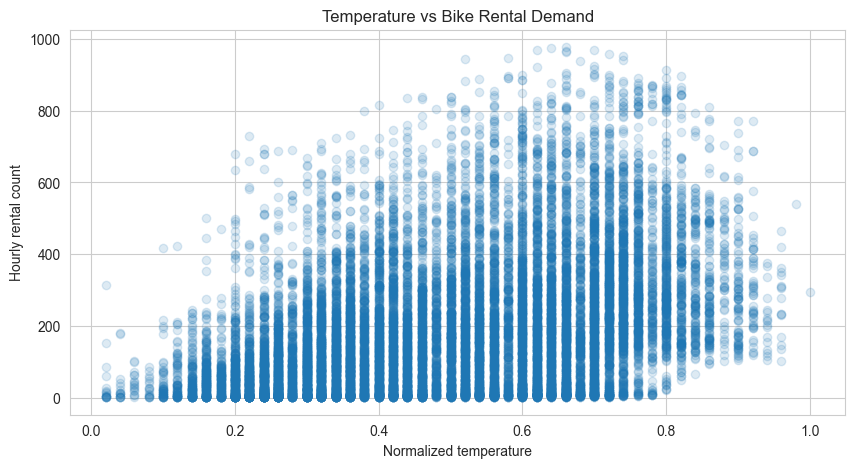

In [105]:
# ==========================================
#   REGRESSION
#  TARGET DISTRIBUTION & NON-LINEARITY
# ==========================================

# 1. Check skewness and variance-to-mean ratio
print("Target mean:", y.mean())
print("Target variance:", y.var())
print("Variance / Mean:", y.var() / y.mean())
print("Target skewness:", y.skew())

# 2. Log-transform check
log_y = np.log1p(y)

print("\nAfter log1p transformation:")
print("Mean:", log_y.mean())
print("Skewness:", log_y.skew())

# 3. Relationship between temperature and demand
plt.figure(figsize=(10, 5))
plt.scatter(df['temp'], df['count'], alpha=0.15)
plt.xlabel('Normalized temperature')
plt.ylabel('Hourly rental count')
plt.title('Temperature vs Bike Rental Demand')
plt.grid(True)
plt.show()

In [106]:
# ==========================================
#  REGRESSION
#  BASELINE OLS REGRESSION
# ==========================================

import statsmodels.formula.api as smf

model_ols = smf.ols(
    formula="""
    count ~ C(season) + C(yr) + C(mnth) + C(hr)
          + C(holiday) + C(weekday) + C(workingday)
          + C(weather)
          + temp + atemp + humidity + windspeed
    """,
    data=df
).fit()

print(model_ols.summary())

                            OLS Regression Results                            
Dep. Variable:                  count   R-squared:                       0.686
Model:                            OLS   Adj. R-squared:                  0.685
Method:                 Least Squares   F-statistic:                     729.1
Date:                Fri, 18 Sep 2026   Prob (F-statistic):               0.00
Time:                        09:22:28   Log-Likelihood:            -1.0497e+05
No. Observations:               17379   AIC:                         2.100e+05
Df Residuals:                   17326   BIC:                         2.104e+05
Df Model:                          52                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept            -83.3317      6

In [107]:
# ==========================================
#  REGRESSION
#  CHECK DESIGN-MATRIX RANK
# ==========================================

import numpy as np

X_design = model_ols.model.exog

print("Number of columns:", X_design.shape[1])
print("Matrix rank:", np.linalg.matrix_rank(X_design))
print("Rank deficiency:", X_design.shape[1] - np.linalg.matrix_rank(X_design))

Number of columns: 54
Matrix rank: 53
Rank deficiency: 1


In [108]:
# ==========================================
#  REGRESSION
# OLS AFTER REMOVING REDUNDANT SEASON
# ==========================================

model_ols2 = smf.ols(
    formula="""
    count ~ C(yr) + C(mnth) + C(hr)
          + C(holiday) + C(weekday) + C(workingday)
          + C(weather)
          + temp + atemp + humidity + windspeed
    """,
    data=df
).fit()

print(model_ols2.summary())

                            OLS Regression Results                            
Dep. Variable:                  count   R-squared:                       0.682
Model:                            OLS   Adj. R-squared:                  0.681
Method:                 Least Squares   F-statistic:                     759.0
Date:                Fri, 18 Sep 2026   Prob (F-statistic):               0.00
Time:                        09:22:29   Log-Likelihood:            -1.0508e+05
No. Observations:               17379   AIC:                         2.103e+05
Df Residuals:                   17329   BIC:                         2.107e+05
Df Model:                          49                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept            -85.7866      6

In [109]:
# ==========================================
#  REGRESSION
#  TEST POSSIBLE STRUCTURAL REDUNDANCY
# ==========================================

# Check the relationship between holiday and workingday
print(pd.crosstab(df['holiday'], df['workingday']))

# Check whether any weekday is always associated with workingday
print("\nWeekday vs Workingday:")
print(pd.crosstab(df['weekday'], df['workingday']))

workingday     0      1
holiday                
0           5014  11865
1            500      0

Weekday vs Workingday:
workingday     0     1
weekday               
0           2502     0
1            357  2122
2             23  2430
3             24  2451
4             48  2423
5             48  2439
6           2512     0


In [110]:
# =======================================
#  REGRESSION
#  CHECK MATRIX RANK AFTER REMOVING SEASON
# ==========================================

X_design2 = model_ols2.model.exog

print("Number of columns:", X_design2.shape[1])
print("Matrix rank:", np.linalg.matrix_rank(X_design2))
print("Rank deficiency:", X_design2.shape[1] - np.linalg.matrix_rank(X_design2))

Number of columns: 51
Matrix rank: 50
Rank deficiency: 1


In [111]:
# ==========================================
#  REGRESSION
#  TEST CALENDAR VARIABLE COMBINATIONS
# ==========================================

formulas = {
    "All calendar variables":
        "C(yr) + C(mnth) + C(hr) + C(holiday) + C(weekday) + C(workingday) + C(weather)",

    "Without holiday":
        "C(yr) + C(mnth) + C(hr) + C(weekday) + C(workingday) + C(weather)",

    "Without workingday":
        "C(yr) + C(mnth) + C(hr) + C(holiday) + C(weekday) + C(weather)",

    "Without weekday":
        "C(yr) + C(mnth) + C(hr) + C(holiday) + C(workingday) + C(weather)"
}

for name, calendar_formula in formulas.items():

    formula = (
        "count ~ " + calendar_formula +
        " + temp + atemp + humidity + windspeed"
    )

    model = smf.ols(formula=formula, data=df).fit()

    X_test = model.model.exog
    columns = X_test.shape[1]
    rank = np.linalg.matrix_rank(X_test)

    print(f"{name}:")
    print(f"  Columns = {columns}")
    print(f"  Rank = {rank}")
    print(f"  Rank deficiency = {columns - rank}")
    print()

All calendar variables:
  Columns = 51
  Rank = 50
  Rank deficiency = 1

Without holiday:
  Columns = 50
  Rank = 50
  Rank deficiency = 0

Without workingday:
  Columns = 50
  Rank = 50
  Rank deficiency = 0

Without weekday:
  Columns = 45
  Rank = 45
  Rank deficiency = 0



In [112]:
# ==========================================
#  REGRESSION
#  FINAL BASELINE OLS
# ==========================================

model_ols_final = smf.ols(
    formula="""
    count ~ C(yr) + C(mnth) + C(hr)
          + C(weekday) + C(workingday)
          + C(weather)
          + temp + atemp + humidity + windspeed
    """,
    data=df
).fit()

print(model_ols_final.summary())

                            OLS Regression Results                            
Dep. Variable:                  count   R-squared:                       0.682
Model:                            OLS   Adj. R-squared:                  0.681
Method:                 Least Squares   F-statistic:                     759.0
Date:                Fri, 18 Sep 2026   Prob (F-statistic):               0.00
Time:                        09:22:33   Log-Likelihood:            -1.0508e+05
No. Observations:               17379   AIC:                         2.103e+05
Df Residuals:                   17329   BIC:                         2.107e+05
Df Model:                          49                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept            -85.3766      6

In [113]:
# ==========================================
#  REGRESSION
#  CLEAN COEFFICIENT TABLE
# ==========================================

coef_table = pd.DataFrame({
    'Variable': model_ols_final.params.index,
    'Coefficient': model_ols_final.params.values,
    'P_value': model_ols_final.pvalues.values
})

coef_table['Significant'] = coef_table['P_value'] < 0.05

display(coef_table)

,Variable,Coefficient,P_value,Significant
0,Intercept,-85.376573,2.463991e-37,True
1,C(yr)[T.1],85.415356,0.000000e+00,True
2,C(mnth)[T.2],3.130114,4.275866e-01,False
3,C(mnth)[T.3],26.942760,4.152726e-11,True
4,C(mnth)[T.4],43.330413,1.275152e-22,True
5,C(mnth)[T.5],56.637205,1.544893e-28,True
6,C(mnth)[T.6],39.984184,2.586528e-12,True
7,C(mnth)[T.7],16.053660,9.657565e-03,True
8,C(mnth)[T.8],37.270702,2.755676e-10,True
9,C(mnth)[T.9],71.570349,1.839310e-41,True


In [114]:
# ==========================================
# NEW TRAIN / TEST SPLIT (as required)
# ==========================================

# Training: days 1 to 20 of every month
# Test:     days 21 to end of every month

train_mask = df['day'] <= 20
test_mask  = df['day'] > 20

train_df = df[train_mask].copy()
test_df  = df[test_mask].copy()

print("=== Official Split Results ===")
print(f"Training set size : {len(train_df)}")
print(f"Test set size     : {len(test_df)}")
print(f"Train ratio       : {len(train_df)/len(df)*100:.1f}%")
print(f"Test ratio        : {len(test_df)/len(df)*100:.1f}%")

print("\nTraining period :", train_df['datetime'].min(), "→", train_df['datetime'].max())
print("Test period     :", test_df['datetime'].min(), "→", test_df['datetime'].max())

print("\nSample of days in Train set:", sorted(train_df['day'].unique()))
print("Sample of days in Test set :", sorted(test_df['day'].unique()))

=== Official Split Results ===
Training set size : 11460
Test set size     : 5919
Train ratio       : 65.9%
Test ratio        : 34.1%

Training period : 2011-01-01 00:00:00 → 2012-12-20 23:00:00
Test period     : 2011-01-21 00:00:00 → 2012-12-31 23:00:00

Sample of days in Train set: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
Sample of days in Test set : [21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]


Residual mean: -1.902826822973915e-13
Residual std: 102.2610119923673
Residual skewness: 0.4312421580686216


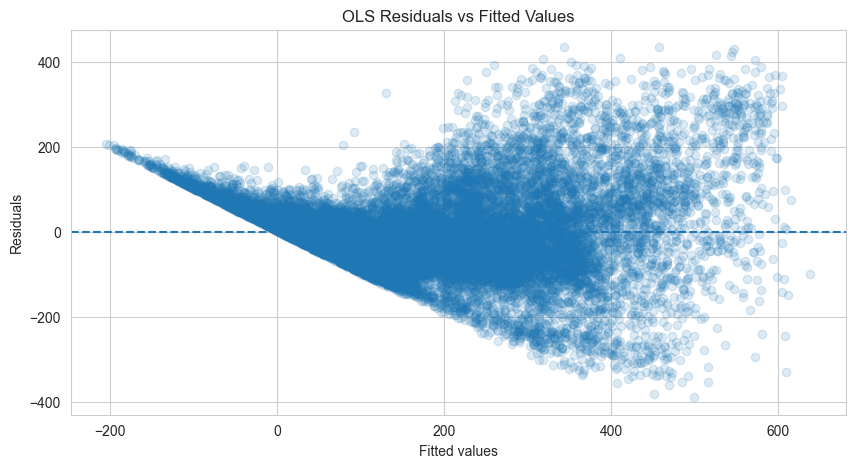

In [115]:
# ==========================================
#  REGRESSION
#  OLS RESIDUAL DIAGNOSTICS
# ==========================================

residuals = model_ols_final.resid
fitted = model_ols_final.fittedvalues

print("Residual mean:", residuals.mean())
print("Residual std:", residuals.std())
print("Residual skewness:", residuals.skew())

# Residuals vs fitted values
plt.figure(figsize=(10, 5))
plt.scatter(fitted, residuals, alpha=0.15)
plt.axhline(0, linestyle='--')
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.title('OLS Residuals vs Fitted Values')
plt.grid(True)
plt.show()

In [116]:
from statsmodels.stats.diagnostic import het_breuschpagan

bp_test = het_breuschpagan(
    model_ols_final.resid,
    model_ols_final.model.exog
)

labels = ['LM Statistic', 'LM p-value', 'F Statistic', 'F p-value']
print(dict(zip(labels, bp_test)))

{'LM Statistic': 5741.7702073586415, 'LM p-value': 0.0, 'F Statistic': 174.49123604691346, 'F p-value': 0.0}


In [117]:
model_ols_robust = model_ols_final.get_robustcov_results(cov_type='HC3')

print(model_ols_robust.summary())

                            OLS Regression Results                            
Dep. Variable:                  count   R-squared:                       0.682
Model:                            OLS   Adj. R-squared:                  0.681
Method:                 Least Squares   F-statistic:                     704.8
Date:                Fri, 18 Sep 2026   Prob (F-statistic):               0.00
Time:                        09:22:34   Log-Likelihood:            -1.0508e+05
No. Observations:               17379   AIC:                         2.103e+05
Df Residuals:                   17329   BIC:                         2.107e+05
Df Model:                          49                                         
Covariance Type:                  HC3                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept            -85.3766      6

In [118]:
import statsmodels.formula.api as smf

model_nb = smf.negativebinomial(
    formula="""
    count ~ C(yr)+C(mnth)+C(hr)
    + C(weekday)+C(workingday)
    + C(weather)
    + temp+atemp+humidity+windspeed
    """,
    data=df
).fit()

print(model_nb.summary())

         Current function value: 5.424714
         Iterations: 35
         Function evaluations: 37
         Gradient evaluations: 37
                     NegativeBinomial Regression Results                      
Dep. Variable:                  count   No. Observations:                17379
Model:               NegativeBinomial   Df Residuals:                    17329
Method:                           MLE   Df Model:                           49
Date:                Fri, 18 Sep 2026   Pseudo R-squ.:                  0.1303
Time:                        09:22:37   Log-Likelihood:                -94276.
converged:                      False   LL-Null:                   -1.0840e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              2.9372      0.036     81.856      0.0

In [119]:
model_nb2 = smf.negativebinomial(
    formula="""
    count ~ C(yr)+C(mnth)+C(hr)
    + C(weekday)+C(workingday)
    + C(weather)
    + temp+humidity+windspeed
    """,
    data=df
).fit(maxiter=200, disp=False)

print(model_nb2.summary())

                     NegativeBinomial Regression Results                      
Dep. Variable:                  count   No. Observations:                17379
Model:               NegativeBinomial   Df Residuals:                    17330
Method:                           MLE   Df Model:                           48
Date:                Fri, 18 Sep 2026   Pseudo R-squ.:                  0.1301
Time:                        09:22:40   Log-Likelihood:                -94291.
converged:                       True   LL-Null:                   -1.0840e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              2.9762      0.036     83.663      0.000       2.906       3.046
C(yr)[T.1]             0.4770      0.008     57.018      0.000       0.461       0.493
C(mnth)[T.2]        

In [120]:
nb_table = pd.DataFrame({
    'Variable': model_nb2.params.index,
    'Coef': model_nb2.params.values,
    'P>|z|': model_nb2.pvalues.values,
    'IRR': np.exp(model_nb2.params.values)
})

display(nb_table)

,Variable,Coef,P>|z|,IRR
0,Intercept,2.976185,0.000000e+00,19.612854
1,C(yr)[T.1],0.477017,0.000000e+00,1.611260
2,C(mnth)[T.2],0.100831,1.909853e-06,1.106090
3,C(mnth)[T.3],0.237572,2.726701e-27,1.268166
4,C(mnth)[T.4],0.369106,6.451125e-55,1.446441
5,C(mnth)[T.5],0.478842,2.249072e-70,1.614204
6,C(mnth)[T.6],0.399084,4.287822e-40,1.490458
7,C(mnth)[T.7],0.311214,1.574486e-21,1.365081
8,C(mnth)[T.8],0.360338,5.278554e-31,1.433814
9,C(mnth)[T.9],0.521243,1.057794e-77,1.684119


In [121]:
# ==========================================
# FEATURE ENGINEERING (No Lookahead Bias)
# ==========================================

def create_features(data):
    df_ = data.copy()
    
    # --- Cyclic time features (known in advance) ---
    df_['hr_sin'] = np.sin(2 * np.pi * df_['hr'] / 24)
    df_['hr_cos'] = np.cos(2 * np.pi * df_['hr'] / 24)
    df_['mnth_sin'] = np.sin(2 * np.pi * df_['mnth'] / 12)
    df_['mnth_cos'] = np.cos(2 * np.pi * df_['mnth'] / 12)
    df_['weekday_sin'] = np.sin(2 * np.pi * df_['weekday'] / 7)
    df_['weekday_cos'] = np.cos(2 * np.pi * df_['weekday'] / 7)
    
    # --- Lag features (strictly past information) ---
    for lag in [1, 2, 3, 24, 48, 168]:  # 1h, 2h, 3h, yesterday, day before, last week
        df_[f'count_lag_{lag}'] = df_['count'].shift(lag)
    
    # --- Rolling statistics from the past only ---
    df_['count_roll_mean_24'] = df_['count'].shift(1).rolling(window=24, min_periods=1).mean()
    df_['count_roll_std_24']  = df_['count'].shift(1).rolling(window=24, min_periods=1).std()
    df_['count_roll_mean_168'] = df_['count'].shift(1).rolling(window=168, min_periods=1).mean()
    
    return df_

# Apply feature engineering on the full dataset (sorted by time)
df_feat = create_features(df)

# Drop rows that have NaN because of lag features (early period)
df_feat = df_feat.dropna().reset_index(drop=True)

print("Feature engineering completed!")
print("New shape after creating lags:", df_feat.shape)
print("\nNew columns added:")
print([col for col in df_feat.columns if 'lag' in col or 'roll' in col or 'sin' in col or 'cos' in col])

Feature engineering completed!
New shape after creating lags: (17211, 34)

New columns added:
['hr_sin', 'hr_cos', 'mnth_sin', 'mnth_cos', 'weekday_sin', 'weekday_cos', 'count_lag_1', 'count_lag_2', 'count_lag_3', 'count_lag_24', 'count_lag_48', 'count_lag_168', 'count_roll_mean_24', 'count_roll_std_24', 'count_roll_mean_168']


In [122]:
print("OLS AIC:", model_ols_final.aic)
print("NB AIC:", model_nb2.aic)

print("\nOLS Log-Likelihood:", model_ols_final.llf)
print("NB Log-Likelihood:", model_nb2.llf)

OLS AIC: 210262.10062025732
NB AIC: 188682.79008206236

OLS Log-Likelihood: -105081.05031012866
NB Log-Likelihood: -94291.39504103118


In [123]:
# Monthly temporal split
train_mask = df['day'] <= 20
test_mask = df['day'] >= 21

train_df = df.loc[train_mask].copy()
test_df = df.loc[test_mask].copy()

print("Training observations:", len(train_df))
print("Testing observations:", len(test_df))

print("\nTraining date range:")
print(train_df['datetime'].min(), "to", train_df['datetime'].max())

print("\nTesting date range:")
print(test_df['datetime'].min(), "to", test_df['datetime'].max())

print("\nTraining days:", sorted(train_df['day'].unique()))
print("Testing days:", sorted(test_df['day'].unique()))

Training observations: 11460
Testing observations: 5919

Training date range:
2011-01-01 00:00:00 to 2012-12-20 23:00:00

Testing date range:
2011-01-21 00:00:00 to 2012-12-31 23:00:00

Training days: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
Testing days: [21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]


In [124]:
# Create leakage-safe lag features using actual timestamps
df_forecast = df.copy()
df_forecast = df_forecast.set_index('datetime').sort_index()

df_forecast['lag_1h'] = df_forecast['count'].reindex(
    df_forecast.index - pd.Timedelta(hours=1)
).values

df_forecast['lag_24h'] = df_forecast['count'].reindex(
    df_forecast.index - pd.Timedelta(hours=24)
).values

df_forecast['lag_168h'] = df_forecast['count'].reindex(
    df_forecast.index - pd.Timedelta(hours=168)
).values

df_forecast = df_forecast.reset_index()

print(df_forecast[
    ['datetime', 'count', 'lag_1h', 'lag_24h', 'lag_168h']
].head(30))

              datetime  count  lag_1h  lag_24h  lag_168h
0  2011-01-01 00:00:00     16     NaN      NaN       NaN
1  2011-01-01 01:00:00     40    16.0      NaN       NaN
2  2011-01-01 02:00:00     32    40.0      NaN       NaN
3  2011-01-01 03:00:00     13    32.0      NaN       NaN
4  2011-01-01 04:00:00      1    13.0      NaN       NaN
5  2011-01-01 05:00:00      1     1.0      NaN       NaN
6  2011-01-01 06:00:00      2     1.0      NaN       NaN
7  2011-01-01 07:00:00      3     2.0      NaN       NaN
8  2011-01-01 08:00:00      8     3.0      NaN       NaN
9  2011-01-01 09:00:00     14     8.0      NaN       NaN
10 2011-01-01 10:00:00     36    14.0      NaN       NaN
11 2011-01-01 11:00:00     56    36.0      NaN       NaN
12 2011-01-01 12:00:00     84    56.0      NaN       NaN
13 2011-01-01 13:00:00     94    84.0      NaN       NaN
14 2011-01-01 14:00:00    106    94.0      NaN       NaN
15 2011-01-01 15:00:00    110   106.0      NaN       NaN
16 2011-01-01 16:00:00     93  

In [125]:
lag_cols = ['lag_1h', 'lag_24h', 'lag_168h']

print("Missing lag values:")
print(df_forecast[lag_cols].isna().sum())

print("\nPercentage missing:")
print((df_forecast[lag_cols].isna().mean() * 100).round(2))

print("\nRows with all lag features available:",
      df_forecast[lag_cols].notna().all(axis=1).sum())

Missing lag values:
lag_1h       76
lag_24h     160
lag_168h    304
dtype: int64

Percentage missing:
lag_1h      0.44
lag_24h     0.92
lag_168h    1.75
dtype: float64

Rows with all lag features available: 16897


In [126]:
print("Train:", train_df['datetime'].min(), "→", train_df['datetime'].max())
print("Test :", test_df['datetime'].min(), "→", test_df['datetime'].max())

print("\nTrain rows:", len(train_df))
print("Test rows :", len(test_df))

print("\nNumber of months in train:", train_df['dteday'].dt.to_period('M').nunique())
print("Number of months in test :", test_df['dteday'].dt.to_period('M').nunique())

Train: 2011-01-01 00:00:00 → 2012-12-20 23:00:00
Test : 2011-01-21 00:00:00 → 2012-12-31 23:00:00

Train rows: 11460
Test rows : 5919

Number of months in train: 24
Number of months in test : 24


In [127]:
df_forecast['hour_sin'] = np.sin(2 * np.pi * df_forecast['hr'] / 24)
df_forecast['hour_cos'] = np.cos(2 * np.pi * df_forecast['hr'] / 24)

df_forecast['month_sin'] = np.sin(2 * np.pi * df_forecast['mnth'] / 12)
df_forecast['month_cos'] = np.cos(2 * np.pi * df_forecast['mnth'] / 12)

print(df_forecast[
    ['datetime', 'hr', 'hour_sin', 'hour_cos',
     'mnth', 'month_sin', 'month_cos']
].head())

             datetime  hr  hour_sin  hour_cos  mnth  month_sin  month_cos
0 2011-01-01 00:00:00   0  0.000000  1.000000     1        0.5   0.866025
1 2011-01-01 01:00:00   1  0.258819  0.965926     1        0.5   0.866025
2 2011-01-01 02:00:00   2  0.500000  0.866025     1        0.5   0.866025
3 2011-01-01 03:00:00   3  0.707107  0.707107     1        0.5   0.866025
4 2011-01-01 04:00:00   4  0.866025  0.500000     1        0.5   0.866025


In [128]:
df_forecast['prev_month_count'] = (
    df_forecast.groupby('hr')['count'].shift(24 * 30)
)

print(df_forecast[
    ['datetime', 'hr', 'count', 'prev_month_count']
].head(50))

              datetime  hr  count  prev_month_count
0  2011-01-01 00:00:00   0     16               NaN
1  2011-01-01 01:00:00   1     40               NaN
2  2011-01-01 02:00:00   2     32               NaN
3  2011-01-01 03:00:00   3     13               NaN
4  2011-01-01 04:00:00   4      1               NaN
5  2011-01-01 05:00:00   5      1               NaN
6  2011-01-01 06:00:00   6      2               NaN
7  2011-01-01 07:00:00   7      3               NaN
8  2011-01-01 08:00:00   8      8               NaN
9  2011-01-01 09:00:00   9     14               NaN
10 2011-01-01 10:00:00  10     36               NaN
11 2011-01-01 11:00:00  11     56               NaN
12 2011-01-01 12:00:00  12     84               NaN
13 2011-01-01 13:00:00  13     94               NaN
14 2011-01-01 14:00:00  14    106               NaN
15 2011-01-01 15:00:00  15    110               NaN
16 2011-01-01 16:00:00  16     93               NaN
17 2011-01-01 17:00:00  17     67               NaN
18 2011-01-0

In [129]:
df_forecast = df_forecast.drop(columns=['prev_month_count'])

In [130]:
count_by_time = df_forecast.set_index('datetime')['count']

df_forecast['history_24h'] = count_by_time.reindex(
    df_forecast['datetime'] - pd.Timedelta(hours=24)
).to_numpy()

df_forecast['history_168h'] = count_by_time.reindex(
    df_forecast['datetime'] - pd.Timedelta(hours=168)
).to_numpy()

print(df_forecast[
    ['datetime', 'count', 'history_24h', 'history_168h']
].head(50))

              datetime  count  history_24h  history_168h
0  2011-01-01 00:00:00     16          NaN           NaN
1  2011-01-01 01:00:00     40          NaN           NaN
2  2011-01-01 02:00:00     32          NaN           NaN
3  2011-01-01 03:00:00     13          NaN           NaN
4  2011-01-01 04:00:00      1          NaN           NaN
5  2011-01-01 05:00:00      1          NaN           NaN
6  2011-01-01 06:00:00      2          NaN           NaN
7  2011-01-01 07:00:00      3          NaN           NaN
8  2011-01-01 08:00:00      8          NaN           NaN
9  2011-01-01 09:00:00     14          NaN           NaN
10 2011-01-01 10:00:00     36          NaN           NaN
11 2011-01-01 11:00:00     56          NaN           NaN
12 2011-01-01 12:00:00     84          NaN           NaN
13 2011-01-01 13:00:00     94          NaN           NaN
14 2011-01-01 14:00:00    106          NaN           NaN
15 2011-01-01 15:00:00    110          NaN           NaN
16 2011-01-01 16:00:00     93  

In [131]:
print("Missing historical features:")
print(df_forecast[['history_24h', 'history_168h']].isna().sum())

print("\nPercentage missing:")
print(
    (df_forecast[['history_24h', 'history_168h']].isna().mean() * 100)
    .round(2)
)

Missing historical features:
history_24h     160
history_168h    304
dtype: int64

Percentage missing:
history_24h     0.92
history_168h    1.75
dtype: float64


In [132]:
df_forecast['month_period'] = df_forecast['datetime'].dt.to_period('M')

df_forecast['forecast_cutoff'] = (
    df_forecast['month_period']
    .dt.to_timestamp()
    + pd.Timedelta(days=20)
)

print(
    df_forecast[
        ['datetime', 'month_period', 'forecast_cutoff', 'day']
    ].iloc[450:475]
)

               datetime month_period forecast_cutoff  day
450 2011-01-20 19:00:00      2011-01      2011-01-21   20
451 2011-01-20 20:00:00      2011-01      2011-01-21   20
452 2011-01-20 21:00:00      2011-01      2011-01-21   20
453 2011-01-20 22:00:00      2011-01      2011-01-21   20
454 2011-01-20 23:00:00      2011-01      2011-01-21   20
455 2011-01-21 00:00:00      2011-01      2011-01-21   21
456 2011-01-21 01:00:00      2011-01      2011-01-21   21
457 2011-01-21 02:00:00      2011-01      2011-01-21   21
458 2011-01-21 03:00:00      2011-01      2011-01-21   21
459 2011-01-21 04:00:00      2011-01      2011-01-21   21
460 2011-01-21 05:00:00      2011-01      2011-01-21   21
461 2011-01-21 06:00:00      2011-01      2011-01-21   21
462 2011-01-21 07:00:00      2011-01      2011-01-21   21
463 2011-01-21 08:00:00      2011-01      2011-01-21   21
464 2011-01-21 09:00:00      2011-01      2011-01-21   21
465 2011-01-21 10:00:00      2011-01      2011-01-21   21
466 2011-01-21

In [133]:
cutoff_check = (
    df_forecast.groupby('month_period')['forecast_cutoff']
    .first()
    .reset_index()
)

print(cutoff_check.to_string(index=False))

month_period forecast_cutoff
     2011-01      2011-01-21
     2011-02      2011-02-21
     2011-03      2011-03-21
     2011-04      2011-04-21
     2011-05      2011-05-21
     2011-06      2011-06-21
     2011-07      2011-07-21
     2011-08      2011-08-21
     2011-09      2011-09-21
     2011-10      2011-10-21
     2011-11      2011-11-21
     2011-12      2011-12-21
     2012-01      2012-01-21
     2012-02      2012-02-21
     2012-03      2012-03-21
     2012-04      2012-04-21
     2012-05      2012-05-21
     2012-06      2012-06-21
     2012-07      2012-07-21
     2012-08      2012-08-21
     2012-09      2012-09-21
     2012-10      2012-10-21
     2012-11      2012-11-21
     2012-12      2012-12-21


In [134]:
# Keep demand only from the training portion of each month
df_forecast['count_train_only'] = np.where(
    df_forecast['day'] <= 20,
    df_forecast['count'],
    np.nan
)

print(
    df_forecast[
        ['datetime', 'day', 'count', 'count_train_only']
    ].iloc[450:475]
)

               datetime  day  count  count_train_only
450 2011-01-20 19:00:00   20    152             152.0
451 2011-01-20 20:00:00   20    126             126.0
452 2011-01-20 21:00:00   20     57              57.0
453 2011-01-20 22:00:00   20     56              56.0
454 2011-01-20 23:00:00   20     31              31.0
455 2011-01-21 00:00:00   21     21               NaN
456 2011-01-21 01:00:00   21      6               NaN
457 2011-01-21 02:00:00   21      2               NaN
458 2011-01-21 03:00:00   21      1               NaN
459 2011-01-21 04:00:00   21      1               NaN
460 2011-01-21 05:00:00   21      5               NaN
461 2011-01-21 06:00:00   21     27               NaN
462 2011-01-21 07:00:00   21     68               NaN
463 2011-01-21 08:00:00   21    217               NaN
464 2011-01-21 09:00:00   21    166               NaN
465 2011-01-21 10:00:00   21     63               NaN
466 2011-01-21 11:00:00   21     59               NaN
467 2011-01-21 12:00:00   21

In [135]:
train_count_by_time = df_forecast.set_index('datetime')['count_train_only']

df_forecast['safe_history_24h'] = train_count_by_time.reindex(
    df_forecast['datetime'] - pd.Timedelta(hours=24)
).to_numpy()

print(
    df_forecast[
        ['datetime', 'day', 'count', 'safe_history_24h']
    ].iloc[450:475]
)

               datetime  day  count  safe_history_24h
450 2011-01-20 19:00:00   20    152             112.0
451 2011-01-20 20:00:00   20    126              76.0
452 2011-01-20 21:00:00   20     57              59.0
453 2011-01-20 22:00:00   20     56              59.0
454 2011-01-20 23:00:00   20     31              28.0
455 2011-01-21 00:00:00   21     21              13.0
456 2011-01-21 01:00:00   21      6               5.0
457 2011-01-21 02:00:00   21      2               2.0
458 2011-01-21 03:00:00   21      1               1.0
459 2011-01-21 04:00:00   21      1               1.0
460 2011-01-21 05:00:00   21      5               6.0
461 2011-01-21 06:00:00   21     27              35.0
462 2011-01-21 07:00:00   21     68             101.0
463 2011-01-21 08:00:00   21    217             249.0
464 2011-01-21 09:00:00   21    166             143.0
465 2011-01-21 10:00:00   21     63              57.0
466 2011-01-21 11:00:00   21     59              68.0
467 2011-01-21 12:00:00   21

In [136]:
df_forecast['safe_history_168h'] = train_count_by_time.reindex(
    df_forecast['datetime'] - pd.Timedelta(hours=168)
).to_numpy()

print(
    df_forecast[
        ['datetime', 'day', 'count',
         'safe_history_24h', 'safe_history_168h']
    ].iloc[455:475]
)

               datetime  day  count  safe_history_24h  safe_history_168h
455 2011-01-21 00:00:00   21     21              13.0               14.0
456 2011-01-21 01:00:00   21      6               5.0                5.0
457 2011-01-21 02:00:00   21      2               2.0                1.0
458 2011-01-21 03:00:00   21      1               1.0                1.0
459 2011-01-21 04:00:00   21      1               1.0                NaN
460 2011-01-21 05:00:00   21      5               6.0                8.0
461 2011-01-21 06:00:00   21     27              35.0               17.0
462 2011-01-21 07:00:00   21     68             101.0               70.0
463 2011-01-21 08:00:00   21    217             249.0              158.0
464 2011-01-21 09:00:00   21    166             143.0              117.0
465 2011-01-21 10:00:00   21     63              57.0               44.0
466 2011-01-21 11:00:00   21     59              68.0               53.0
467 2011-01-21 12:00:00   21     78              84

In [137]:
safe_cols = ['safe_history_24h', 'safe_history_168h']

print("Missing values:")
print(df_forecast[safe_cols].isna().sum())

print("\nMissing percentage:")
print(
    (df_forecast[safe_cols].isna().mean() * 100).round(2)
)

print("\nAvailable individually:")
print(df_forecast[safe_cols].notna().sum())

print("\nBoth available:")
print(df_forecast[safe_cols].notna().all(axis=1).sum())

Missing values:
safe_history_24h     5970
safe_history_168h    6001
dtype: int64

Missing percentage:
safe_history_24h     34.35
safe_history_168h    34.53
dtype: float64

Available individually:
safe_history_24h     11409
safe_history_168h    11378
dtype: int64

Both available:
7953


In [138]:
test_forecast = df_forecast[df_forecast['day'] >= 21].copy()

print("Test rows:", len(test_forecast))

print("\nHistorical feature availability in TEST:")
print(
    test_forecast[
        ['safe_history_24h', 'safe_history_168h']
    ].notna().sum()
)

print("\nHistorical feature missingness in TEST (%):")
print(
    (test_forecast[
        ['safe_history_24h', 'safe_history_168h']
    ].isna().mean() * 100).round(2)
)

print("\nBoth historical features available in TEST:")
print(
    test_forecast[
        ['safe_history_24h', 'safe_history_168h']
    ].notna().all(axis=1).sum()
)

Test rows: 5919

Historical feature availability in TEST:
safe_history_24h      572
safe_history_168h    3961
dtype: int64

Historical feature missingness in TEST (%):
safe_history_24h     90.34
safe_history_168h    33.08
dtype: float64

Both historical features available in TEST:
571


In [139]:
forecast_features = [
    'season', 'yr', 'mnth', 'hr',
    'weekday', 'workingday', 'weather',
    'temp', 'atemp', 'humidity', 'windspeed',
    'hour_sin', 'hour_cos',
    'month_sin', 'month_cos'
]

train_forecast = df_forecast[df_forecast['day'] <= 20].copy()
test_forecast = df_forecast[df_forecast['day'] >= 21].copy()

X_train = train_forecast[forecast_features]
y_train = train_forecast['count']

X_test = test_forecast[forecast_features]
y_test = test_forecast['count']

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

print("\nMissing values:")
print("X_train:", X_train.isna().sum().sum())
print("X_test :", X_test.isna().sum().sum())

X_train: (11460, 15)
y_train: (11460,)
X_test : (5919, 15)
y_test : (5919,)

Missing values:
X_train: 0
X_test : 0


In [140]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

rf_baseline = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_baseline.fit(X_train, y_train)

y_pred_rf = rf_baseline.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Baseline")
print("----------------------")
print(f"MAE : {mae_rf:.3f}")
print(f"RMSE: {rmse_rf:.3f}")
print(f"R²  : {r2_rf:.3f}")

Random Forest Baseline
----------------------
MAE : 36.630
RMSE: 62.847
R²  : 0.880


In [141]:
test_results = test_forecast[['datetime', 'count']].copy()
test_results['prediction'] = y_pred_rf
test_results['month'] = test_results['datetime'].dt.to_period('M')

monthly_metrics = []

for month, group in test_results.groupby('month'):
    y_true = group['count']
    y_pred = group['prediction']
    
    monthly_metrics.append({
        'month': str(month),
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R2': r2_score(y_true, y_pred)
    })

monthly_metrics = pd.DataFrame(monthly_metrics)

display(monthly_metrics)

print("\nAverage monthly metrics:")
print(monthly_metrics[['MAE', 'RMSE', 'R2']].mean())

print("\nMedian monthly metrics:")
print(monthly_metrics[['MAE', 'RMSE', 'R2']].median())

,month,MAE,RMSE,R2
0,2011-01,11.546125,18.232079,0.852135
1,2011-02,18.622122,28.492358,0.795581
2,2011-03,14.910604,24.086367,0.900116
3,2011-04,52.462241,77.188624,0.719526
4,2011-05,24.502311,37.656335,0.935789
5,2011-06,21.026566,30.035224,0.965134
6,2011-07,35.408320,53.603113,0.818872
7,2011-08,32.485979,62.508829,0.850280
8,2011-09,35.550155,54.237270,0.872267
9,2011-10,26.432835,40.970722,0.908393



Average monthly metrics:
MAE     36.330054
RMSE    56.585322
R2       0.705989
dtype: float64

Median monthly metrics:
MAE     33.897987
RMSE    53.085440
R2       0.900526
dtype: float64


In [142]:
strict_features = [
    'season', 'yr', 'mnth', 'hr',
    'weekday', 'workingday',
    'hour_sin', 'hour_cos',
    'month_sin', 'month_cos'
]

X_train_strict = train_forecast[strict_features]
X_test_strict = test_forecast[strict_features]

rf_strict = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_strict.fit(X_train_strict, y_train)

y_pred_strict = rf_strict.predict(X_test_strict)

mae_strict = mean_absolute_error(y_test, y_pred_strict)
rmse_strict = np.sqrt(mean_squared_error(y_test, y_pred_strict))
r2_strict = r2_score(y_test, y_pred_strict)

print("Strict Calendar-Only Random Forest")
print("-----------------------------------")
print(f"MAE : {mae_strict:.3f}")
print(f"RMSE: {rmse_strict:.3f}")
print(f"R²  : {r2_strict:.3f}")

Strict Calendar-Only Random Forest
-----------------------------------
MAE : 47.173
RMSE: 82.311
R²  : 0.793


In [143]:
history_features = strict_features + ['safe_history_168h']

# Training rows: historical feature must be available
train_hist = train_forecast.dropna(subset=['safe_history_168h']).copy()

# Test rows where historical demand is available
test_hist = test_forecast.dropna(subset=['safe_history_168h']).copy()

X_train_hist = train_hist[history_features]
y_train_hist = train_hist['count']

X_test_hist = test_hist[history_features]
y_test_hist = test_hist['count']

rf_history = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_history.fit(X_train_hist, y_train_hist)

pred_hist = rf_history.predict(X_test_hist)

print("Rows with 168-hour history:")
print("Training:", len(train_hist))
print("Testing :", len(test_hist))

print("\nHistorical-demand RF performance")
print("--------------------------------")
print(f"MAE : {mean_absolute_error(y_test_hist, pred_hist):.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_hist, pred_hist)):.3f}")
print(f"R²  : {r2_score(y_test_hist, pred_hist):.3f}")

Rows with 168-hour history:
Training: 7417
Testing : 3961

Historical-demand RF performance
--------------------------------
MAE : 55.008
RMSE: 94.082
R²  : 0.734


In [144]:
# Calendar-only predictions on the same rows used by the history model
X_test_common = test_hist[strict_features]

pred_calendar_common = rf_strict.predict(X_test_common)

print("Same test subset:", len(test_hist))

print("\nCalendar-only RF on common subset")
print("--------------------------------")
print(f"MAE : {mean_absolute_error(y_test_hist, pred_calendar_common):.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_hist, pred_calendar_common)):.3f}")
print(f"R²  : {r2_score(y_test_hist, pred_calendar_common):.3f}")

print("\nCalendar + 168h history RF")
print("---------------------------")
print(f"MAE : {mean_absolute_error(y_test_hist, pred_hist):.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_hist, pred_hist)):.3f}")
print(f"R²  : {r2_score(y_test_hist, pred_hist):.3f}")

Same test subset: 3961

Calendar-only RF on common subset
--------------------------------
MAE : 47.920
RMSE: 84.014
R²  : 0.788

Calendar + 168h history RF
---------------------------
MAE : 55.008
RMSE: 94.082
R²  : 0.734


In [145]:
from sklearn.ensemble import GradientBoostingRegressor

gbr_strict = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    min_samples_leaf=5,
    loss='squared_error',
    random_state=42
)

gbr_strict.fit(X_train_strict, y_train)

y_pred_gbr = gbr_strict.predict(X_test_strict)

mae_gbr = mean_absolute_error(y_test, y_pred_gbr)
rmse_gbr = np.sqrt(mean_squared_error(y_test, y_pred_gbr))
r2_gbr = r2_score(y_test, y_pred_gbr)

print("Strict Gradient Boosting Regressor")
print("----------------------------------")
print(f"MAE : {mae_gbr:.3f}")
print(f"RMSE: {rmse_gbr:.3f}")
print(f"R²  : {r2_gbr:.3f}")

Strict Gradient Boosting Regressor
----------------------------------
MAE : 46.480
RMSE: 78.305
R²  : 0.813


In [146]:
gbr_results = test_forecast[['datetime', 'count']].copy()

gbr_results['prediction'] = y_pred_gbr
gbr_results['month'] = gbr_results['datetime'].dt.to_period('M')

gbr_monthly = []

for month, group in gbr_results.groupby('month'):
    y_true = group['count']
    y_pred = group['prediction']
    
    gbr_monthly.append({
        'month': str(month),
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R2': r2_score(y_true, y_pred)
    })

gbr_monthly = pd.DataFrame(gbr_monthly)

display(gbr_monthly)

print("\nAverage monthly metrics:")
print(gbr_monthly[['MAE', 'RMSE', 'R2']].mean())

print("\nMedian monthly metrics:")
print(gbr_monthly[['MAE', 'RMSE', 'R2']].median())

print("\nWorst 5 months by R²:")
display(
    gbr_monthly.sort_values('R2').head(5)
)

,month,MAE,RMSE,R2
0,2011-01,16.934602,25.292313,0.715442
1,2011-02,24.540246,37.248489,0.650634
2,2011-03,19.842548,33.949267,0.801566
3,2011-04,67.876993,91.129868,0.609062
4,2011-05,28.818998,42.838706,0.916899
5,2011-06,22.172177,32.675290,0.958736
6,2011-07,37.386933,55.135738,0.808366
7,2011-08,44.090489,82.855768,0.736948
8,2011-09,40.791110,60.863205,0.839152
9,2011-10,39.053584,72.376797,0.714122



Average monthly metrics:
MAE     46.205090
RMSE    71.292798
R2       0.564672
dtype: float64

Median monthly metrics:
MAE     42.220070
RMSE    62.784103
R2       0.804966
dtype: float64

Worst 5 months by R²:


,month,MAE,RMSE,R2
23,2012-12,122.976616,169.849079,-3.704643
11,2011-12,56.507775,78.394335,0.096456
10,2011-11,53.330205,82.489434,0.415904
22,2012-11,75.229230,115.435438,0.482563
3,2011-04,67.876993,91.129868,0.609062


In [147]:
dec_2012 = gbr_results[
    gbr_results['month'] == '2012-12'
].copy()

dec_2012['error'] = dec_2012['prediction'] - dec_2012['count']
dec_2012['abs_error'] = dec_2012['error'].abs()

print("December 2012 actual demand:")
print(f"Mean actual     : {dec_2012['count'].mean():.2f}")
print(f"Mean prediction : {dec_2012['prediction'].mean():.2f}")

print("\nPrediction error:")
print(f"Mean error      : {dec_2012['error'].mean():.2f}")
print(f"Mean abs error  : {dec_2012['abs_error'].mean():.2f}")

print("\nFirst 10 December observations:")
display(
    dec_2012[['datetime', 'count', 'prediction', 'error']].head(10)
)

December 2012 actual demand:
Mean actual     : 78.66
Mean prediction : 200.23

Prediction error:
Mean error      : 121.57
Mean abs error  : 122.98

First 10 December observations:


,datetime,count,prediction,error
17117,2012-12-21 00:00:00,17,55.246112,38.246112
17118,2012-12-21 01:00:00,9,26.048705,17.048705
17119,2012-12-21 02:00:00,3,14.379671,11.379671
17120,2012-12-21 03:00:00,3,8.442439,5.442439
17121,2012-12-21 04:00:00,6,7.199569,1.199569
17122,2012-12-21 05:00:00,13,18.813012,5.813012
17123,2012-12-21 06:00:00,80,110.821479,30.821479
17124,2012-12-21 07:00:00,208,294.932108,86.932108
17125,2012-12-21 08:00:00,472,595.336873,123.336873
17126,2012-12-21 09:00:00,267,311.631494,44.631494


In [148]:
display(
    dec_2012[
        ['datetime', 'count', 'prediction', 'error']
    ].head(24)
)

,datetime,count,prediction,error
17117,2012-12-21 00:00:00,17,55.246112,38.246112
17118,2012-12-21 01:00:00,9,26.048705,17.048705
17119,2012-12-21 02:00:00,3,14.379671,11.379671
17120,2012-12-21 03:00:00,3,8.442439,5.442439
17121,2012-12-21 04:00:00,6,7.199569,1.199569
17122,2012-12-21 05:00:00,13,18.813012,5.813012
17123,2012-12-21 06:00:00,80,110.821479,30.821479
17124,2012-12-21 07:00:00,208,294.932108,86.932108
17125,2012-12-21 08:00:00,472,595.336873,123.336873
17126,2012-12-21 09:00:00,267,311.631494,44.631494


In [149]:
dec_summary = (
    dec_2012
    .groupby(dec_2012['datetime'].dt.day)
    .agg(
        actual_mean=('count', 'mean'),
        prediction_mean=('prediction', 'mean'),
        mae=('abs_error', 'mean')
    )
)

display(dec_summary)

,actual_mean,prediction_mean,mae
datetime,,,
21,150.958333,214.828658,63.870325
22,72.875000,208.110079,135.610875
23,74.458333,158.399532,84.484408
24,40.000000,216.405119,176.405119
25,44.043478,209.242445,165.198967
26,18.375000,199.814880,181.439880
27,88.083333,207.703194,119.619860
28,128.958333,214.828658,86.963908
29,55.875000,208.110079,152.235079


In [150]:
# Historical mean demand by hour and working-day status
hist_profile = (
    train_forecast
    .groupby(['hr', 'workingday'])['count']
    .mean()
    .rename('historical_hour_workday_mean')
    .reset_index()
)

train_profile = train_forecast.merge(
    hist_profile,
    on=['hr', 'workingday'],
    how='left'
)

test_profile = test_forecast.merge(
    hist_profile,
    on=['hr', 'workingday'],
    how='left'
)

print("Training rows:", len(train_profile))
print("Test rows:", len(test_profile))
print("Missing historical profile - train:",
      train_profile['historical_hour_workday_mean'].isna().sum())
print("Missing historical profile - test:",
      test_profile['historical_hour_workday_mean'].isna().sum())

Training rows: 11460
Test rows: 5919
Missing historical profile - train: 0
Missing historical profile - test: 0


In [151]:
profile_features = strict_features + ['historical_hour_workday_mean']

X_train_profile = train_profile[profile_features]
y_train_profile = train_profile['count']

X_test_profile = test_profile[profile_features]
y_test_profile = test_profile['count']

gbr_profile = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    min_samples_leaf=5,
    loss='squared_error',
    random_state=42
)

gbr_profile.fit(X_train_profile, y_train_profile)

y_pred_profile = gbr_profile.predict(X_test_profile)

profile_mae = mean_absolute_error(y_test_profile, y_pred_profile)
profile_rmse = mean_squared_error(y_test_profile, y_pred_profile) ** 0.5
profile_r2 = r2_score(y_test_profile, y_pred_profile)

print("Profile-enhanced GBR")
print(f"MAE  : {profile_mae:.3f}")
print(f"RMSE : {profile_rmse:.3f}")
print(f"R²   : {profile_r2:.3f}")

print("\nPrevious strict GBR")
print(f"MAE  : 46.480")
print(f"RMSE : 78.305")
print(f"R²   : 0.813")

Profile-enhanced GBR
MAE  : 45.789
RMSE : 78.622
R²   : 0.812

Previous strict GBR
MAE  : 46.480
RMSE : 78.305
R²   : 0.813


In [152]:
dec_2011 = gbr_results[gbr_results['month'] == '2011-12'].copy()

dec_2011['error'] = dec_2011['prediction'] - dec_2011['count']
dec_2011['abs_error'] = dec_2011['error'].abs()

print("December 2011:")
print(f"Mean actual     : {dec_2011['count'].mean():.2f}")
print(f"Mean prediction : {dec_2011['prediction'].mean():.2f}")
print(f"Mean error      : {dec_2011['error'].mean():.2f}")
print(f"MAE             : {dec_2011['abs_error'].mean():.2f}")

print("\nDaily summary:")
dec_2011_summary = (
    dec_2011
    .groupby(dec_2011['datetime'].dt.day)
    .agg(
        actual_mean=('count', 'mean'),
        prediction_mean=('prediction', 'mean'),
        mae=('abs_error', 'mean')
    )
)

display(dec_2011_summary)

December 2011:
Mean actual     : 85.79
Mean prediction : 129.83
Mean error      : 44.04
MAE             : 56.51

Daily summary:


,actual_mean,prediction_mean,mae
datetime,,,
21,110.833333,115.462063,28.618779
22,127.833333,130.970264,41.091904
23,92.041667,142.195061,64.027554
24,42.125000,127.287224,85.703727
25,32.782609,116.989868,84.394413
26,57.260870,138.842664,81.581795
27,48.416667,134.746275,86.893554
28,100.086957,120.588270,34.316667
29,100.958333,130.970264,37.847126


In [153]:
train_profile['late_december'] = (
    (train_profile['mnth'] == 12) &
    (train_profile['day'] >= 24)
).astype(int)

test_profile['late_december'] = (
    (test_profile['mnth'] == 12) &
    (test_profile['day'] >= 24)
).astype(int)

print("Training late-December rows:",
      train_profile['late_december'].sum())

print("Test late-December rows:",
      test_profile['late_december'].sum())

Training late-December rows: 0
Test late-December rows: 379


In [154]:
# ==========================================
# MODEL TRAINING & EVALUATION (Clean Version)
# ==========================================

models = {
    'Ridge': Ridge(alpha=1.0),
    'RandomForest': RandomForestRegressor(
        n_estimators=200, 
        max_depth=12, 
        n_jobs=-1, 
        random_state=42
    ),
    'GradientBoosting': GradientBoostingRegressor(
        n_estimators=200, 
        max_depth=5, 
        learning_rate=0.05, 
        random_state=42
    )
}

results = {}

print("Training models... Please wait.\n")

for name, model in models.items():
    model.fit(X_train, y_train)
    
    pred = model.predict(X_test)
    pred = np.maximum(pred, 0)  # counts cannot be negative
    
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mae  = mean_absolute_error(y_test, pred)
    r2   = r2_score(y_test, pred)
    
    results[name] = {
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2,
        'pred': pred
    }
    
    print(f"{name:20s} →  RMSE: {rmse:.2f}  |  MAE: {mae:.2f}  |  R²: {r2:.4f}")

print("\nTraining completed!")

Training models... Please wait.

Ridge                →  RMSE: 130.34  |  MAE: 94.58  |  R²: 0.4820
RandomForest         →  RMSE: 64.37  |  MAE: 38.15  |  R²: 0.8737
GradientBoosting     →  RMSE: 61.15  |  MAE: 38.04  |  R²: 0.8860

Training completed!


In [155]:
# ==========================================
# CLEAN REBUILD - Feature Engineering + Models
# ==========================================

# 1. Create features again
def create_features(data):
    df_ = data.copy()
    
    df_['hr_sin'] = np.sin(2 * np.pi * df_['hr'] / 24)
    df_['hr_cos'] = np.cos(2 * np.pi * df_['hr'] / 24)
    df_['mnth_sin'] = np.sin(2 * np.pi * df_['mnth'] / 12)
    df_['mnth_cos'] = np.cos(2 * np.pi * df_['mnth'] / 12)
    df_['weekday_sin'] = np.sin(2 * np.pi * df_['weekday'] / 7)
    df_['weekday_cos'] = np.cos(2 * np.pi * df_['weekday'] / 7)
    
    for lag in [1, 2, 3, 24, 48, 168]:
        df_[f'count_lag_{lag}'] = df_['count'].shift(lag)
    
    df_['count_roll_mean_24'] = df_['count'].shift(1).rolling(24, min_periods=1).mean()
    df_['count_roll_std_24']  = df_['count'].shift(1).rolling(24, min_periods=1).std()
    df_['count_roll_mean_168'] = df_['count'].shift(1).rolling(168, min_periods=1).mean()
    
    return df_

df_feat = create_features(df)
df_feat = df_feat.dropna().reset_index(drop=True)

# 2. Official split
train_mask = df_feat['day'] <= 20
test_mask  = df_feat['day'] > 20

feature_cols = [
    'hr', 'hr_sin', 'hr_cos',
    'mnth', 'mnth_sin', 'mnth_cos',
    'weekday', 'weekday_sin', 'weekday_cos',
    'holiday', 'workingday', 'season',
    'temp', 'humidity', 'windspeed', 'weather',
    'count_lag_1', 'count_lag_2', 'count_lag_3',
    'count_lag_24', 'count_lag_48', 'count_lag_168',
    'count_roll_mean_24', 'count_roll_std_24', 'count_roll_mean_168'
]

X_train = df_feat.loc[train_mask, feature_cols]
y_train = df_feat.loc[train_mask, 'count']
X_test  = df_feat.loc[test_mask, feature_cols]
y_test  = df_feat.loc[test_mask, 'count']

print("Shapes → X_train:", X_train.shape, "| X_test:", X_test.shape)

# 3. Train models
models = {
    'Ridge': Ridge(alpha=1.0),
    'RandomForest': RandomForestRegressor(n_estimators=200, max_depth=12, n_jobs=-1, random_state=42),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=200, max_depth=5, learning_rate=0.05, random_state=42)
}

print("\nTraining...\n")

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = np.maximum(model.predict(X_test), 0)
    
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mae  = mean_absolute_error(y_test, pred)
    r2   = r2_score(y_test, pred)
    
    print(f"{name:20s} → RMSE: {rmse:.2f} | MAE: {mae:.2f} | R²: {r2:.4f}")

Shapes → X_train: (11292, 25) | X_test: (5919, 25)

Training...

Ridge                → RMSE: 67.18 | MAE: 44.84 | R²: 0.8624
RandomForest         → RMSE: 40.03 | MAE: 23.84 | R²: 0.9511
GradientBoosting     → RMSE: 36.64 | MAE: 23.32 | R²: 0.9591


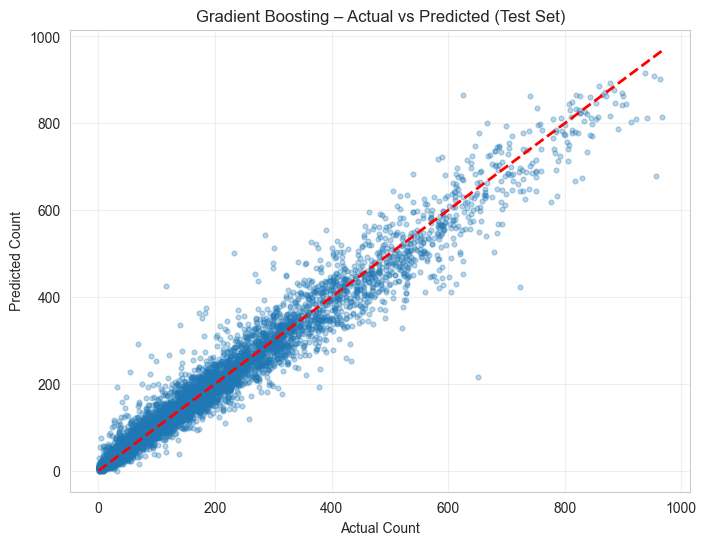

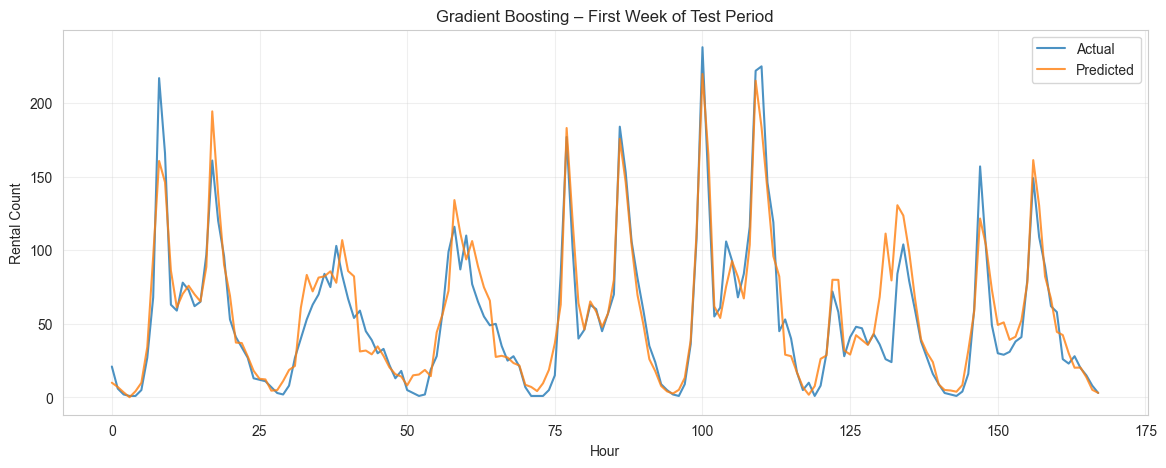

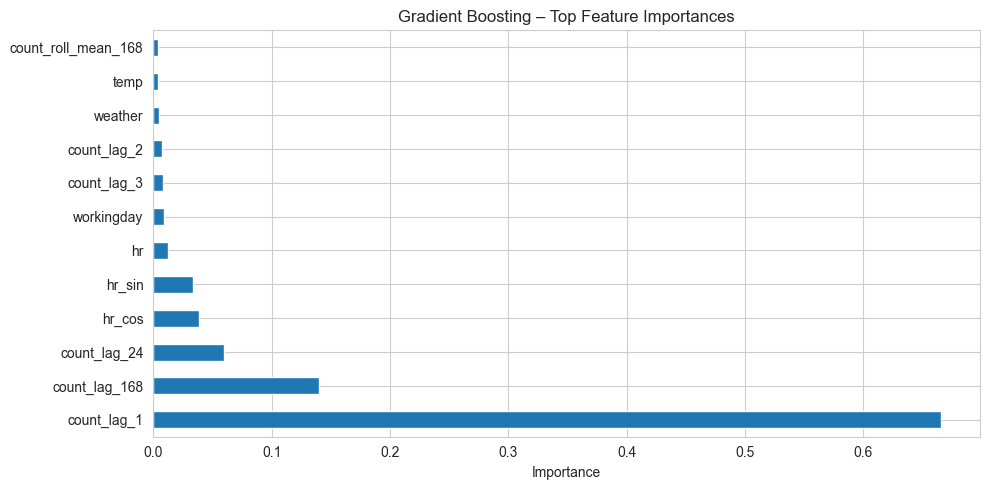

Top 10 most important features:
count_lag_1      0.665526
count_lag_168    0.139881
count_lag_24     0.059996
hr_cos           0.038462
hr_sin           0.033496
hr               0.012222
workingday       0.008999
count_lag_3      0.007994
count_lag_2      0.007577
weather          0.004449
dtype: float64


In [156]:
# ==========================================
# VISUALIZATION + FEATURE IMPORTANCE
# ==========================================

best_model = models['GradientBoosting']
best_pred = np.maximum(best_model.predict(X_test), 0)

# 1. Actual vs Predicted scatter
plt.figure(figsize=(8, 6))
plt.scatter(y_test, best_pred, alpha=0.3, s=12)
plt.plot([0, y_test.max()], [0, y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Count')
plt.ylabel('Predicted Count')
plt.title('Gradient Boosting – Actual vs Predicted (Test Set)')
plt.grid(True, alpha=0.3)
plt.show()

# 2. Time series sample (first 7 days of test data)
plt.figure(figsize=(14, 5))
sample = 24 * 7   # one week
plt.plot(y_test.values[:sample], label='Actual', alpha=0.8)
plt.plot(best_pred[:sample], label='Predicted', alpha=0.8)
plt.title('Gradient Boosting – First Week of Test Period')
plt.xlabel('Hour')
plt.ylabel('Rental Count')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 3. Feature Importance
importance = pd.Series(best_model.feature_importances_, index=feature_cols)
importance = importance.sort_values(ascending=False).head(12)

plt.figure(figsize=(10, 5))
importance.plot(kind='barh')
plt.title('Gradient Boosting – Top Feature Importances')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print("Top 10 most important features:")
print(importance.head(10))

In [157]:
# ==========================================
# REGRESSION ANALYSIS
# ==========================================

# We use the original df (before lag features) for explanatory regression
reg_df = df.copy()

# One-hot encode categorical variables
reg_df = pd.get_dummies(reg_df, columns=['season', 'weather', 'weekday'], drop_first=True, dtype=float)

# Candidate features
feature_cols_reg = [
    'holiday', 'workingday', 'temp', 'atemp', 'humidity', 'windspeed', 'hr',
    'season_2', 'season_3', 'season_4',
    'weather_2', 'weather_3', 'weather_4',
    'weekday_1', 'weekday_2', 'weekday_3', 'weekday_4', 'weekday_5', 'weekday_6'
]

X_reg = reg_df[feature_cols_reg]
y_reg = reg_df['count']

print("Regression feature matrix shape:", X_reg.shape)

Regression feature matrix shape: (17379, 19)


In [158]:
X_vif = sm.add_constant(X_reg)

vif_data = pd.DataFrame()
vif_data['feature'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

print("=== Variance Inflation Factors (VIF) ===")
print(vif_data.sort_values('VIF', ascending=False).round(2))

=== Variance Inflation Factors (VIF) ===
       feature           VIF
14   weekday_1  1.000800e+15
2   workingday  1.000800e+15
18   weekday_5  1.000800e+15
17   weekday_4  1.000800e+15
16   weekday_3  1.000800e+15
1      holiday  1.000800e+15
15   weekday_2  1.000800e+15
3         temp  4.847000e+01
4        atemp  4.526000e+01
9     season_3  4.090000e+00
8     season_2  2.440000e+00
10    season_4  1.820000e+00
19   weekday_6  1.720000e+00
5     humidity  1.530000e+00
12   weather_3  1.260000e+00
6    windspeed  1.220000e+00
11   weather_2  1.150000e+00
7           hr  1.140000e+00
13   weather_4  1.000000e+00
0        const  1.000000e+00


In [159]:
# Drop atemp because of high multicollinearity with temp
feature_cols_clean = [col for col in feature_cols_reg if col != 'atemp']
X_clean = reg_df[feature_cols_clean]

X_ols = sm.add_constant(X_clean)
ols_model = sm.OLS(y_reg, X_ols).fit()

print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  count   R-squared:                       0.351
Model:                            OLS   Adj. R-squared:                  0.350
Method:                 Least Squares   F-statistic:                     552.4
Date:                Fri, 18 Sep 2026   Prob (F-statistic):               0.00
Time:                        09:23:44   Log-Likelihood:            -1.1128e+05
No. Observations:               17379   AIC:                         2.226e+05
Df Residuals:                   17361   BIC:                         2.227e+05
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         23.8441      7.367      3.237      0.0

In [160]:
# ==========================================
# CLEAN REGRESSION (Fixed Multicollinearity)
# ==========================================

reg_df = df.copy()

# One-hot encode only season and weather (avoid weekday dummy trap)
reg_df = pd.get_dummies(reg_df, columns=['season', 'weather'], drop_first=True, dtype=float)

# Better feature set
feature_cols_clean = [
    'holiday', 'workingday', 'hr',
    'temp', 'humidity', 'windspeed',
    'season_2', 'season_3', 'season_4',
    'weather_2', 'weather_3', 'weather_4'
]

X_clean = reg_df[feature_cols_clean]
y_reg = reg_df['count']

# Check VIF again
X_vif = sm.add_constant(X_clean)
vif_data = pd.DataFrame({
    'feature': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})
print("=== Cleaned VIF ===")
print(vif_data.sort_values('VIF', ascending=False).round(2))
print()

# OLS
X_ols = sm.add_constant(X_clean)
ols_model = sm.OLS(y_reg, X_ols).fit()
print(ols_model.summary())

=== Cleaned VIF ===
       feature   VIF
8     season_3  4.05
4         temp  2.81
7     season_2  2.44
9     season_4  1.81
5     humidity  1.52
11   weather_3  1.26
10   weather_2  1.15
6    windspeed  1.15
3           hr  1.14
2   workingday  1.07
1      holiday  1.07
12   weather_4  1.00
0        const  1.00

                            OLS Regression Results                            
Dep. Variable:                  count   R-squared:                       0.351
Model:                            OLS   Adj. R-squared:                  0.350
Method:                 Least Squares   F-statistic:                     781.4
Date:                Fri, 18 Sep 2026   Prob (F-statistic):               0.00
Time:                        09:23:45   Log-Likelihood:            -1.1129e+05
No. Observations:               17379   AIC:                         2.226e+05
Df Residuals:                   17366   BIC:                         2.227e+05
Df Model:                          12                

In [161]:
print(ols_model.params.round(2))
print("\nP-values:")
print(ols_model.pvalues.round(4))

const          31.76
holiday       -26.71
workingday      2.58
hr              7.27
temp          378.49
humidity     -212.90
windspeed      14.78
season_2       15.13
season_3      -16.85
season_4       60.44
weather_2      12.34
weather_3     -25.49
weather_4      70.40
dtype: float64

P-values:
const         0.0000
holiday       0.0001
workingday    0.2956
hr            0.0000
temp          0.0000
humidity      0.0000
windspeed     0.1283
season_2      0.0001
season_3      0.0010
season_4      0.0000
weather_2     0.0000
weather_3     0.0000
weather_4     0.4048
dtype: float64


In [162]:
# Poisson GLM (more suitable for count data)
poisson_model = sm.GLM(y_reg, X_ols, family=sm.families.Poisson()).fit()

print("=== Poisson Regression Coefficients ===")
print(poisson_model.params.round(4))
print("\nP-values:")
print(poisson_model.pvalues.round(4))

=== Poisson Regression Coefficients ===
const         4.0452
holiday      -0.1632
workingday    0.0126
hr            0.0450
temp          1.9099
humidity     -1.0610
windspeed     0.1920
season_2      0.1943
season_3      0.0414
season_4      0.4621
weather_2     0.0879
weather_3    -0.2391
weather_4     0.2017
dtype: float64

P-values:
const         0.0000
holiday       0.0000
workingday    0.0000
hr            0.0000
temp          0.0000
humidity      0.0000
windspeed     0.0000
season_2      0.0000
season_3      0.0000
season_4      0.0000
weather_2     0.0000
weather_3     0.0000
weather_4     0.0026
dtype: float64


In [163]:
import numpy as np
import pandas as pd
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Cyclical Features
df['hr_sin'] = np.sin(2 * np.pi * df['hr'] / 24.0)
df['hr_cos'] = np.cos(2 * np.pi * df['hr'] / 24.0)
df['mnth_sin'] = np.sin(2 * np.pi * df['mnth'] / 12.0)
df['mnth_cos'] = np.cos(2 * np.pi * df['mnth'] / 12.0)
df['weekday_sin'] = np.sin(2 * np.pi * df['weekday'] / 7.0)
df['weekday_cos'] = np.cos(2 * np.pi * df['weekday'] / 7.0)

# 2. Split: Days 1-20 (Train), Days 21+ (Test)
train_df = df[df['day'] <= 20].copy()
test_df = df[df['day'] > 20].copy()

# 3. Target Encoding (Strictly computed on Train set to prevent lookahead bias)
train_means = train_df.groupby(['hr', 'workingday'])['count'].mean().reset_index().rename(columns={'count': 'target_enc_hr_workingday'})
train_df = train_df.merge(train_means, on=['hr', 'workingday'], how='left')
test_df = test_df.merge(train_means, on=['hr', 'workingday'], how='left')

feature_cols = [
    'hr_sin', 'hr_cos', 'mnth_sin', 'mnth_cos', 'weekday_sin', 'weekday_cos',
    'workingday', 'holiday', 'yr', 'temp', 'humidity', 'windspeed', 'weather',
    'target_enc_hr_workingday'
]

X_train, y_train = train_df[feature_cols], train_df['count']
X_test, y_test = test_df[feature_cols], test_df['count']

# 4. Evaluate
for name, model in [('Ridge', Ridge()), ('Random Forest', RandomForestRegressor(n_estimators=100, random_state=42)), ('Gradient Boosting', GradientBoostingRegressor(n_estimators=100, random_state=42))]:
    model.fit(X_train, y_train)
    preds = np.clip(model.predict(X_test), 0, None)
    print(f"{name:18s} | RMSE: {np.sqrt(mean_squared_error(y_test, preds)):.2f} | MAE: {mean_absolute_error(y_test, preds):.2f} | R²: {r2_score(y_test, preds):.4f}")

Ridge              | RMSE: 85.27 | MAE: 58.53 | R²: 0.7783
Random Forest      | RMSE: 66.94 | MAE: 38.09 | R²: 0.8634
Gradient Boosting  | RMSE: 63.06 | MAE: 39.01 | R²: 0.8788
